# 20260908 · HCF2 손실 모델 수정 및 실제 실행 검증

**실측값에 fitting하지 않은 계산**을 비교합니다. 10–15% 목표 달성을 보장하지 않습니다.
수정 주 모델은 **vector 7영역 동심 근사**입니다. 기존 scalar 5영역/7영역과 추가 vector 9영역 형상 가정도 모두 표시합니다.

아래 출력은 제공된 Python/IPython 커널에서 실제 실행되었습니다. **Colab 웹에서 실행한 것은 아닙니다.**
파일을 열면 실행된 표와 그래프를 바로 볼 수 있습니다. Colab에서 모두 재실행할 수 있도록 코드와 원자료 CSV를 내장했습니다.

비교 대상은 Petrovich et al., Nature Photonics 19, 1203–1208 (2025), DOI [10.1038/s41566-025-01747-5](https://doi.org/10.1038/s41566-025-01747-5)의 **HCF2**입니다.
계산값은 **leakage only**, 논문값은 **measured total**입니다. 이 차이를 총손실 예측 정확도로 오해하면 안 됩니다.

In [1]:
import sys, subprocess, importlib.util
required = {'numpy':'numpy', 'scipy':'scipy', 'pandas':'pandas',
            'matplotlib':'matplotlib', 'mpmath':'mpmath'}
missing = [pkg for mod,pkg in required.items() if importlib.util.find_spec(mod) is None]
if missing:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', *missing])
from pathlib import Path
import json, io, hashlib, types, platform, datetime, importlib.metadata
import numpy as np
import pandas as pd
from IPython.display import display, Image, Markdown
OUT=Path('validated_results');OUT.mkdir(exist_ok=True)
environment={'python':sys.version,'platform':platform.platform(),
             'packages':{p:importlib.metadata.version(p) for p in
                         ['numpy','scipy','pandas','matplotlib','mpmath','ipython']},
             'execution':'actual IPython kernel; Colab web UI not used',
             'executed_at_utc':datetime.datetime.now(datetime.timezone.utc).isoformat()}
display(environment)

{'python': '3.12.13 (main, Aug  7 2026, 02:25:39) [Clang 22.1.3 ]',
 'platform': 'Linux-6.18.35-x86_64-with-glibc2.39',
 'packages': {'numpy': '2.3.5',
  'scipy': '1.17.0',
  'pandas': '2.2.3',
  'matplotlib': '3.10.8',
  'mpmath': '1.4.1',
  'ipython': '9.17.1'},
 'execution': 'actual IPython kernel; Colab web UI not used',
 'executed_at_utc': '2026-09-08T04:01:45.773604+00:00'}

## 구현 코드와 입력 동결

Bird Eqs. (4)–(8)의 네 접선장 경계조건과 exact Bessel/Hankel 기저를 사용합니다.
코드에는 HCF2 손실 보정계수가 없습니다. 아래 세 모듈은 저장소 소스를 그대로 내장한 것입니다.

In [2]:
# Embedded source: hcf_concentric_tmm_20260908.py
MODULE_SOURCE = '"""Scalar concentric leaky-mode solver for hollow-core antiresonant surrogates.\n\nThis is a research/diagnostic model, not a full-vector DNANF FEM replacement.\nIt solves the scalar radial Helmholtz equation in arbitrary concentric annuli,\nwith a regular J_m core field and a purely outgoing H_m^(1) exterior field.\n\nTime/axial convention: exp(i*beta*z - i*omega*t).  A decaying mode therefore\nhas Im(beta) > 0 and power attenuation 2*Im(beta) [Np/m].\n"""\n\nfrom __future__ import annotations\n\nfrom dataclasses import asdict, dataclass\nfrom typing import Iterable, Sequence\n\nimport numpy as np\nfrom scipy import optimize, special\n\n\nU01 = float(special.jn_zeros(0, 1)[0])\nDB_PER_NEPER_POWER = 10.0 / np.log(10.0)\n\n\ndef silica_index_sellmeier(wavelength_m: float) -> float:\n    """Malitson fused-silica Sellmeier index; wavelength is in metres."""\n    lam_um = float(wavelength_m) * 1e6\n    b = np.array([0.6961663, 0.4079426, 0.8974794])\n    c_um = np.array([0.0684043, 0.1162414, 9.896161])\n    n_sq = 1.0 + np.sum(b * lam_um**2 / (lam_um**2 - c_um**2))\n    return float(np.sqrt(n_sq))\n\n\ndef _radiation_sqrt(z: complex) -> complex:\n    """Choose transverse-wave-number branch with Re(q)>=0."""\n    q = complex(np.sqrt(complex(z)))\n    if q.real < 0.0 or (abs(q.real) < 1e-15 and q.imag > 0.0):\n        q = -q\n    return q\n\n\n@dataclass(frozen=True)\nclass ConcentricLeakyModeModel:\n    """Core + finite annuli + infinite exterior.\n\n    `annulus_indices` and `annulus_thickness_um` describe only the finite\n    annuli between the core and the infinite exterior.\n    """\n\n    name: str\n    core_radius_um: float\n    annulus_indices: tuple[float, ...]\n    annulus_thickness_um: tuple[float, ...]\n    n_core: float = 1.0\n    n_outer: float = 1.0\n    azimuthal_order: int = 0\n\n    def __post_init__(self) -> None:\n        if self.core_radius_um <= 0:\n            raise ValueError("core_radius_um must be positive")\n        if len(self.annulus_indices) != len(self.annulus_thickness_um):\n            raise ValueError("annulus_indices and annulus_thickness_um must have equal length")\n        if any(n <= 0 for n in self.annulus_indices):\n            raise ValueError("all refractive indices must be positive")\n        if any(t <= 0 for t in self.annulus_thickness_um):\n            raise ValueError("all annulus thicknesses must be positive")\n\n    @property\n    def core_radius_m(self) -> float:\n        return self.core_radius_um * 1e-6\n\n    @property\n    def annulus_thickness_m(self) -> tuple[float, ...]:\n        return tuple(t * 1e-6 for t in self.annulus_thickness_um)\n\n    @property\n    def boundary_radii_m(self) -> np.ndarray:\n        return np.cumsum((self.core_radius_m, *self.annulus_thickness_m))\n\n    @property\n    def region_indices(self) -> tuple[float, ...]:\n        return (self.n_core, *self.annulus_indices, self.n_outer)\n\n\n@dataclass(frozen=True)\nclass ModeSolution:\n    model_name: str\n    wavelength_nm: float\n    converged: bool\n    u_real: float\n    u_imag: float\n    beta_real_per_m: float\n    beta_imag_per_m: float\n    neff_real: float\n    neff_imag: float\n    loss_db_km: float\n    characteristic_abs: float\n    direct_transfer_residual_abs: float\n    relative_smallest_singular_value: float\n    root_message: str\n    roots_found: int\n\n    def to_dict(self) -> dict:\n        return asdict(self)\n\n\ndef beta_from_u(u: complex, wavelength_m: float, core_radius_m: float, n_core: float = 1.0) -> complex:\n    """Convert dimensionless core transverse parameter u=q_core*a to beta."""\n    k0 = 2.0 * np.pi / wavelength_m\n    beta = complex(np.sqrt(complex((n_core * k0) ** 2 - (u / core_radius_m) ** 2)))\n    if beta.real < 0.0:\n        beta = -beta\n    # exp(i beta z-i omega t): choose the axially decaying resonance.\n    if beta.imag < 0.0:\n        beta = beta.conjugate()\n    return beta\n\n\ndef _region_basis(\n    region_number: int,\n    region_count: int,\n    n: float,\n    beta: complex,\n    k0: float,\n    r: float,\n    m: int,\n) -> np.ndarray:\n    """Return basis columns [field; (1/k0)*d(field)/dr]."""\n    q = _radiation_sqrt((n * k0) ** 2 - beta**2)\n    x = q * r\n    derivative_factor = q / k0\n\n    if region_number == 0:  # regular at r=0: J_m only\n        return np.array(\n            [[special.jv(m, x)], [derivative_factor * special.jvp(m, x, 1)]],\n            dtype=complex,\n        )\n    if region_number == region_count - 1:  # outgoing at infinity: H_m^(1) only\n        return np.array(\n            [[special.hankel1(m, x)], [derivative_factor * special.h1vp(m, x, 1)]],\n            dtype=complex,\n        )\n    return np.array(\n        [\n            [special.jv(m, x), special.yv(m, x)],\n            [\n                derivative_factor * special.jvp(m, x, 1),\n                derivative_factor * special.yvp(m, x, 1),\n            ],\n        ],\n        dtype=complex,\n    )\n\n\ndef _jy_basis(n: float, beta: complex, k0: float, r: float, m: int) -> np.ndarray:\n    """Two-column J_m/Y_m basis used by the explicit coefficient TMM."""\n    q = _radiation_sqrt((n * k0) ** 2 - beta**2)\n    x = q * r\n    return np.array(\n        [\n            [special.jv(m, x), special.yv(m, x)],\n            [(q / k0) * special.jvp(m, x, 1), (q / k0) * special.yvp(m, x, 1)],\n        ],\n        dtype=complex,\n    )\n\n\ndef direct_transfer_outgoing_residual(\n    u: complex, wavelength_m: float, model: ConcentricLeakyModeModel\n) -> complex:\n    """Explicit transfer-matrix cross-check.\n\n    At interface r_i, c_(i+1)=F_(i+1)^(-1)F_i c_i.  The regular core has\n    c_core=[1,0].  In the outer J/Y basis an outgoing H^(1)=J+iY wave obeys\n    B_out-i*A_out=0.  Repeated transfer is less stable than the global block\n    determinant, so it is used as a diagnostic rather than the root objective.\n    """\n    k0 = 2.0 * np.pi / wavelength_m\n    beta = beta_from_u(u, wavelength_m, model.core_radius_m, model.n_core)\n    coefficients = np.array([1.0 + 0.0j, 0.0 + 0.0j])\n    for interface, radius in enumerate(model.boundary_radii_m):\n        left = _jy_basis(\n            model.region_indices[interface], beta, k0, radius, model.azimuthal_order\n        )\n        right = _jy_basis(\n            model.region_indices[interface + 1], beta, k0, radius, model.azimuthal_order\n        )\n        coefficients = np.linalg.solve(right, left @ coefficients)\n        coefficients /= max(float(np.max(np.abs(coefficients))), 1e-300)\n    return complex(coefficients[1] - 1j * coefficients[0])\n\n\ndef matching_matrix(u: complex, wavelength_m: float, model: ConcentricLeakyModeModel) -> np.ndarray:\n    """Block matrix enforcing field and derivative continuity at every boundary.\n\n    Each pair of block columns is equivalent to the usual transfer relation\n    c_(i+1) = F_(i+1)^(-1) F_i c_i.  The global block form avoids repeatedly\n    multiplying poorly conditioned transfer matrices.\n    """\n    k0 = 2.0 * np.pi / wavelength_m\n    beta = beta_from_u(u, wavelength_m, model.core_radius_m, model.n_core)\n    indices = model.region_indices\n    boundaries = model.boundary_radii_m\n    region_count = len(indices)\n    dimensions = [1] + [2] * len(model.annulus_indices) + [1]\n    starts = np.cumsum([0] + dimensions[:-1])\n    matrix = np.zeros((2 * (region_count - 1), sum(dimensions)), dtype=complex)\n\n    for interface, radius in enumerate(boundaries):\n        left = _region_basis(\n            interface,\n            region_count,\n            indices[interface],\n            beta,\n            k0,\n            radius,\n            model.azimuthal_order,\n        )\n        right = _region_basis(\n            interface + 1,\n            region_count,\n            indices[interface + 1],\n            beta,\n            k0,\n            radius,\n            model.azimuthal_order,\n        )\n        rows = slice(2 * interface, 2 * interface + 2)\n        matrix[rows, starts[interface] : starts[interface] + dimensions[interface]] = left\n        matrix[\n            rows,\n            starts[interface + 1] : starts[interface + 1] + dimensions[interface + 1],\n        ] = -right\n    return matrix\n\n\ndef characteristic(u: complex, wavelength_m: float, model: ConcentricLeakyModeModel) -> complex:\n    """Column-scaled characteristic determinant; its zeros are the leaky modes."""\n    matrix = matching_matrix(u, wavelength_m, model)\n    scales = np.max(np.abs(matrix), axis=0)\n    if np.any(~np.isfinite(scales)) or np.any(scales == 0.0):\n        return complex(np.nan, np.nan)\n    return complex(np.linalg.det(matrix / scales))\n\n\ndef beta_loss_db_km(beta: complex) -> float:\n    """Power attenuation: 2*Im(beta)*(10/ln(10))*1000."""\n    return float(2.0 * abs(beta.imag) * DB_PER_NEPER_POWER * 1000.0)\n\n\ndef _root_residual(x: Sequence[float], wavelength_m: float, model: ConcentricLeakyModeModel) -> np.ndarray:\n    value = characteristic(complex(float(x[0]), float(x[1])), wavelength_m, model)\n    if not np.isfinite(value.real) or not np.isfinite(value.imag):\n        return np.array([1e6, 1e6])\n    return np.array([value.real, value.imag])\n\n\ndef solve_fundamental_mode(\n    wavelength_nm: float,\n    model: ConcentricLeakyModeModel,\n    real_seeds: Iterable[float] | None = None,\n    imag_seeds: Iterable[float] | None = None,\n    maxfev: int = 5000,\n    determinant_tolerance: float = 1e-8,\n    singular_value_tolerance: float = 1e-10,\n) -> ModeSolution:\n    """Multi-start complex root search near the scalar LP01/HE11 surrogate.\n\n    A candidate is accepted only when both the characteristic determinant and\n    the relative smallest singular value independently confirm singularity.\n    No number is returned as a valid loss if those checks fail.\n    """\n    wavelength_m = wavelength_nm * 1e-9\n    if real_seeds is None:\n        real_seeds = (U01 - 0.08, U01, U01 + 0.08)\n    if imag_seeds is None:\n        imag_seeds = (-1e-2, -1e-3, -1e-4, -1e-5, -1e-6, -1e-7, -1e-8)\n\n    candidates: list[tuple[complex, object, float, float]] = []\n    messages: list[str] = []\n    best_diagnostic: tuple[float, complex, float, float, str] | None = None\n    for ur in real_seeds:\n        for ui in imag_seeds:\n            result = optimize.root(\n                _root_residual,\n                np.array([ur, ui], dtype=float),\n                args=(wavelength_m, model),\n                method="hybr",\n                options={"xtol": 1e-11, "maxfev": maxfev},\n            )\n            messages.append(str(result.message))\n            u = complex(float(result.x[0]), float(result.x[1]))\n            # Restrict to the low-radial-order resonance branch. Extremely\n            # negative Im(u) roots are mathematically valid but are not the\n            # core-like fundamental sought here.\n            if not (1.5 < u.real < 3.5 and -1.0 < u.imag < 0.0):\n                continue\n            det_abs = abs(characteristic(u, wavelength_m, model))\n            singular_values = np.linalg.svd(matching_matrix(u, wavelength_m, model), compute_uv=False)\n            relative_smin = float(singular_values[-1] / singular_values[0])\n            score = max(\n                det_abs / determinant_tolerance,\n                relative_smin / singular_value_tolerance,\n            )\n            if best_diagnostic is None or score < best_diagnostic[0]:\n                best_diagnostic = (score, u, det_abs, relative_smin, str(result.message))\n            if det_abs <= determinant_tolerance and relative_smin <= singular_value_tolerance:\n                if not any(abs(u - old[0]) < 1e-6 for old in candidates):\n                    candidates.append((u, result, det_abs, relative_smin))\n\n    if not candidates:\n        if best_diagnostic is None:\n            detail = "No optimizer result stayed on 1.5<Re(u)<3.5 and -1<Im(u)<0."\n        else:\n            _, u_best, det_best, smin_best, optimizer_message = best_diagnostic\n            detail = (\n                f"Best low-order candidate u={u_best.real:.9g}{u_best.imag:+.3g}j, "\n                f"|det|={det_best:.3e} (limit {determinant_tolerance:.1e}), "\n                f"relative smin={smin_best:.3e} (limit {singular_value_tolerance:.1e}); "\n                f"optimizer: {optimizer_message}"\n            )\n        return ModeSolution(\n            model_name=model.name,\n            wavelength_nm=float(wavelength_nm),\n            converged=False,\n            u_real=np.nan,\n            u_imag=np.nan,\n            beta_real_per_m=np.nan,\n            beta_imag_per_m=np.nan,\n            neff_real=np.nan,\n            neff_imag=np.nan,\n            loss_db_km=np.nan,\n            characteristic_abs=np.nan,\n            direct_transfer_residual_abs=np.nan,\n            relative_smallest_singular_value=np.nan,\n            root_message="No independently verified fundamental-like root. " + detail,\n            roots_found=0,\n        )\n\n    # The scalar fundamental is the accepted root whose real part is nearest u01.\n    u, result, det_abs, relative_smin = min(candidates, key=lambda item: abs(item[0].real - U01))\n    beta = beta_from_u(u, wavelength_m, model.core_radius_m, model.n_core)\n    neff = beta / (2.0 * np.pi / wavelength_m)\n    return ModeSolution(\n        model_name=model.name,\n        wavelength_nm=float(wavelength_nm),\n        converged=True,\n        u_real=float(u.real),\n        u_imag=float(u.imag),\n        beta_real_per_m=float(beta.real),\n        beta_imag_per_m=float(beta.imag),\n        neff_real=float(neff.real),\n        neff_imag=float(neff.imag),\n        loss_db_km=beta_loss_db_km(beta),\n        characteristic_abs=float(det_abs),\n        direct_transfer_residual_abs=float(\n            abs(direct_transfer_outgoing_residual(u, wavelength_m, model))\n        ),\n        relative_smallest_singular_value=float(relative_smin),\n        root_message=str(result.message),\n        roots_found=len(candidates),\n    )\n\n\ndef bouncing_ray_te_loss_db_km(\n    wavelength_nm: float,\n    core_radius_um: float = 14.75,\n    wall_thickness_um: float = 0.50,\n    silica_index: float | None = None,\n) -> float:\n    """TE-like single-wall thin-wall bouncing-ray/ARROW estimate.\n\n    This is the appropriate closed-form comparator for the unweighted scalar\n    field/derivative continuity used by this notebook.  A hybrid HE11 estimate\n    generally combines TE- and TM-like contributions and need not equal it.\n    """\n    wavelength_m = wavelength_nm * 1e-9\n    a = core_radius_um * 1e-6\n    t = wall_thickness_um * 1e-6\n    k0 = 2.0 * np.pi / wavelength_m\n    n = silica_index_sellmeier(wavelength_m) if silica_index is None else float(silica_index)\n    kappa = U01 / a\n    sigma = k0 * np.sqrt(n**2 - 1.0)\n    phase = sigma * t\n    denominator = 4.0 * np.cos(phase) ** 2 + (\n        kappa / sigma + sigma / kappa\n    ) ** 2 * np.sin(phase) ** 2\n    alpha_per_m = 2.0 * U01 / (a**2 * k0 * denominator)\n    return float(alpha_per_m * DB_PER_NEPER_POWER * 1000.0)\n\n\ndef bache_bouncing_ray_loss_db_km(\n    wavelength_nm: float,\n    polarization: str = "hybrid",\n    core_radius_um: float = 14.75,\n    wall_thickness_um: float = 0.50,\n    silica_index: float | None = None,\n) -> float:\n    """Bache et al. Eqs. (15)-(17), without an FEM fitting factor.\n\n    ``polarization`` may be ``TE``, ``TM`` or ``hybrid``.  The hybrid HE11-like\n    result is the arithmetic mean of the TE and TM power-loss coefficients,\n    exactly as stated in Eq. (17) of the paper.  This function deliberately\n    does *not* apply the paper\'s design-specific ``f_FEM`` multiplier.\n    """\n    wavelength_m = wavelength_nm * 1e-9\n    a = core_radius_um * 1e-6\n    t = wall_thickness_um * 1e-6\n    k0 = 2.0 * np.pi / wavelength_m\n    n = silica_index_sellmeier(wavelength_m) if silica_index is None else float(silica_index)\n    kappa = U01 / a\n    sigma = k0 * np.sqrt(n**2 - 1.0)\n    phase = sigma * t\n    prefactor = 2.0 * U01 / (a**2 * k0)\n\n    denominator_te = 4.0 * np.cos(phase) ** 2 + (\n        kappa / sigma + sigma / kappa\n    ) ** 2 * np.sin(phase) ** 2\n    denominator_tm = 4.0 * np.cos(phase) ** 2 + (\n        n**2 * kappa / sigma + sigma / (n**2 * kappa)\n    ) ** 2 * np.sin(phase) ** 2\n    te = prefactor / denominator_te * DB_PER_NEPER_POWER * 1000.0\n    tm = prefactor / denominator_tm * DB_PER_NEPER_POWER * 1000.0\n\n    key = polarization.strip().lower()\n    if key == "te":\n        return float(te)\n    if key == "tm":\n        return float(tm)\n    if key in {"hybrid", "he11"}:\n        return float((te + tm) / 2.0)\n    raise ValueError("polarization must be \'TE\', \'TM\', or \'hybrid\'")\n\n\ndef multilayer_bouncing_ray_loss_db_km(\n    wavelength_nm: float,\n    layer_indices: Sequence[float],\n    layer_thickness_um: Sequence[float],\n    polarization: str = "hybrid",\n    core_radius_um: float = 14.75,\n) -> float:\n    """Planar multilayer extension of Bache\'s bouncing-ray loss.\n\n    The incidence angle is fixed by the MS transverse wave number ``u01/a``.\n    A standard lossless characteristic matrix returns the power reflectance of\n    the finite stack.  The per-bounce transmission is then converted with\n    Bache Eq. (6).  The result is geometry-only: no Petrovich loss value, FEM\n    result, fitted scale factor, or regression coefficient is used.\n\n    This is a useful independent cross-check of the concentric TMM, but it is\n    still a one-dimensional radial surrogate and omits azimuthal confinement.\n    """\n    if len(layer_indices) != len(layer_thickness_um):\n        raise ValueError("layer_indices and layer_thickness_um must have equal length")\n    if not layer_indices:\n        raise ValueError("at least one finite layer is required")\n\n    wavelength_m = wavelength_nm * 1e-9\n    a = core_radius_um * 1e-6\n    k0 = 2.0 * np.pi / wavelength_m\n    beta = np.sqrt(k0**2 - (U01 / a) ** 2 + 0j)\n    indices = [1.0, *map(float, layer_indices), 1.0]\n    q = [_radiation_sqrt((n * k0) ** 2 - beta**2) for n in indices]\n\n    def one_pol(pol: str) -> float:\n        if pol == "te":\n            admittance = [qi / k0 for qi in q]\n        elif pol == "tm":\n            admittance = [n**2 * k0 / qi for n, qi in zip(indices, q)]\n        else:\n            raise ValueError("internal polarization must be te or tm")\n\n        matrix = np.eye(2, dtype=complex)\n        for region, thickness_um in enumerate(layer_thickness_um, start=1):\n            phase = q[region] * float(thickness_um) * 1e-6\n            y = admittance[region]\n            layer_matrix = np.array(\n                [\n                    [np.cos(phase), 1j * np.sin(phase) / y],\n                    [1j * y * np.sin(phase), np.cos(phase)],\n                ],\n                dtype=complex,\n            )\n            matrix = matrix @ layer_matrix\n\n        a11, a12, a21, a22 = matrix.ravel()\n        y_in = (a21 + a22 * admittance[-1]) / (\n            a11 + a12 * admittance[-1]\n        )\n        reflection = (admittance[0] - y_in) / (admittance[0] + y_in)\n        transmission_per_bounce = max(0.0, 1.0 - float(abs(reflection) ** 2))\n        bounce_rate = U01 / (2.0 * a**2 * k0)\n        alpha_per_m = transmission_per_bounce * bounce_rate\n        return float(alpha_per_m * DB_PER_NEPER_POWER * 1000.0)\n\n    key = polarization.strip().lower()\n    if key == "te":\n        return one_pol("te")\n    if key == "tm":\n        return one_pol("tm")\n    if key in {"hybrid", "he11"}:\n        return float((one_pol("te") + one_pol("tm")) / 2.0)\n    raise ValueError("polarization must be \'TE\', \'TM\', or \'hybrid\'")\n\n\ndef build_models(\n    wavelength_nm: float,\n    gap1_um: float,\n    gap2_um: float | None = None,\n    core_radius_um: float = 14.75,\n    wall_thickness_um: float = 0.50,\n    fixed_silica_index: float | None = None,\n) -> dict[str, ConcentricLeakyModeModel]:\n    """Create the requested 3/5-layer models and optional 7-layer diagnostic."""\n    n_si = (\n        silica_index_sellmeier(wavelength_nm * 1e-9)\n        if fixed_silica_index is None\n        else float(fixed_silica_index)\n    )\n    models = {\n        "3-layer": ConcentricLeakyModeModel(\n            "3-layer: air | silica | outgoing air",\n            core_radius_um,\n            (n_si,),\n            (wall_thickness_um,),\n        ),\n        "5-layer": ConcentricLeakyModeModel(\n            "5-layer: air | silica | air gap | silica | outgoing air",\n            core_radius_um,\n            (n_si, 1.0, n_si),\n            (wall_thickness_um, gap1_um, wall_thickness_um),\n        ),\n    }\n    if gap2_um is not None:\n        models["7-layer"] = ConcentricLeakyModeModel(\n            "7-layer diagnostic: air | silica | gap | silica | gap | silica | outgoing air",\n            core_radius_um,\n            (n_si, 1.0, n_si, 1.0, n_si),\n            (wall_thickness_um, gap1_um, wall_thickness_um, gap2_um, wall_thickness_um),\n        )\n    return models\n\n\ndef solve_models(\n    wavelengths_nm: Iterable[float],\n    gap1_um: float,\n    gap2_um: float | None = None,\n    **model_kwargs,\n) -> list[ModeSolution]:\n    solutions: list[ModeSolution] = []\n    for wavelength_nm in wavelengths_nm:\n        for model in build_models(wavelength_nm, gap1_um, gap2_um, **model_kwargs).values():\n            solutions.append(solve_fundamental_mode(wavelength_nm, model))\n    return solutions\n\n\nif __name__ == "__main__":\n    # Public HCF2 midpoint diameters under an internally tangent radial mapping:\n    # gap1=(31.05-2*0.50)-23.75=6.30 um; gap2=(23.75-2*0.50)-7.70=15.05 um.\n    for solution in solve_models((1310.0, 1550.0), gap1_um=6.30, gap2_um=15.05):\n        print(solution.to_dict())\n'
module = types.ModuleType('hcf_concentric_tmm_20260908')
module.__file__ = 'hcf_concentric_tmm_20260908.py'
sys.modules['hcf_concentric_tmm_20260908'] = module
exec(compile(MODULE_SOURCE, module.__file__, 'exec'), module.__dict__)
print('Loaded hcf_concentric_tmm_20260908; SHA256:', hashlib.sha256(MODULE_SOURCE.encode()).hexdigest())

Loaded hcf_concentric_tmm_20260908; SHA256: 669ea3d9206d4ae9dab18a07b8e06325878b05b2892e64611820fbbccab7160e


In [3]:
# Embedded source: hcf_vector_tmm.py
MODULE_SOURCE = '"""Unfitted full-vector *concentric* Maxwell leaky-mode diagnostic.\n\nNot a model of the actual 5-tube DNANF cross section and not total attenuation.\nConvention exp(i beta z + i m phi - i omega t); only Im(beta)>0 is accepted.\nFields matched at each interface: Ez, Z0*Hz, Ephi, Z0*Hphi.\nThe geometry/container and Sellmeier inputs are retained from the user\'s TMM.\nReference: Bird, Opt. Express 25, 23215 (2017), Eqs. (4)-(8), (25).\nOur complex exp(i*m*phi) basis is equivalent to Bird\'s sine/cosine basis.\nExact Bessel functions are used, not the asymptotic Hankel approximation.\n"""\nfrom __future__ import annotations\n\nfrom dataclasses import dataclass, asdict\nimport numpy as np\nfrom scipy import optimize, special\n\nfrom hcf_concentric_tmm_20260908 import ConcentricLeakyModeModel, U01\n\n\ndef full_chord_model(wavelength_nm, core_radius_um=14.75,\n                     large_um=31.05, middle_um=23.75, small_um=7.70,\n                     wall_um=0.50):\n    """Full radial chord of three internally tangent tubes (9 regions).\n\n    The old 7-region surrogate stops after the small tube\'s *near* wall.\n    This geometry-derived alternative retains its air bore and the three\n    contiguous far walls (3*t). The internally tangent, equal-thickness\n    assumption is explicit; the real 5-tube azimuthal geometry is still absent.\n    Parameters and layer selection must never be tuned to attenuation data.\n    """\n    from hcf_concentric_tmm_20260908 import silica_index_sellmeier\n    n=silica_index_sellmeier(wavelength_nm*1e-9)\n    g1=large_um-2*wall_um-middle_um\n    g2=middle_um-2*wall_um-small_um\n    inner_bore=small_um-2*wall_um\n    if min(g1,g2,inner_bore)<=0:\n        raise ValueError("Nonpositive gap/bore in tangent geometry")\n    return ConcentricLeakyModeModel("9-layer full-chord concentric diagnostic",\n        core_radius_um,(n,1.,n,1.,n,1.,n),\n        (wall_um,g1,wall_um,g2,wall_um,inner_bore,3*wall_um))\n\n\n@dataclass(frozen=True)\nclass VectorSolution:\n    wavelength_nm: float\n    layers: int\n    u_real: float\n    u_imag: float\n    loss_db_km: float\n    neff_real: float\n    neff_imag: float\n    matching_smin_ratio: float\n    outgoing_smin_ratio: float\n    determinant_abs: float\n    root_count: int\n    converged: bool\n\n    def to_dict(self):\n        return asdict(self)\n\n\ndef _parameters(u, wavelength_nm, model, n):\n    # Units in this solver are micrometres.  Compute q without cancellation.\n    k = 2*np.pi/(wavelength_nm*1e-3)\n    qc = u/model.core_radius_um\n    q = np.sqrt(complex((n*n-model.n_core**2)*k*k + qc*qc))\n    if q.real < 0:\n        q = -q\n    beta = np.sqrt(complex(model.n_core**2*k*k-qc*qc))\n    if beta.real < 0:\n        beta = -beta\n    return k, q, beta\n\n\ndef _basis(u, wavelength_nm, model, n, radius_um, kind="both", m=1):\n    """Maxwell basis; longitudinal E/H columns, no scalar approximation.\n\n    Ephi = -beta*m/(q^2*r)*Ez - i*k0/q^2*d(Z0 Hz)/dr\n    Z0 Hphi = i*k0*n^2/q^2*dEz/dr - beta*m/(q^2*r)*(Z0 Hz).\n    This is the exact boundary-condition formulation, not Bird\'s asymptotic\n    Hankel expansion or Bache\'s single-FEM-scale empirical extension.\n    """\n    k,q,beta = _parameters(u,wavelength_nm,model,n)\n    x=q*radius_um\n    if kind == "core":\n        f=np.array([special.jv(m,x)]); fp=np.array([special.jvp(m,x)])\n    elif kind == "outer":\n        f=np.array([special.hankel1(m,x)]); fp=np.array([special.h1vp(m,x)])\n    else:\n        f=np.array([special.jv(m,x),special.yv(m,x)])\n        fp=np.array([special.jvp(m,x),special.yvp(m,x)])\n    count=len(f)\n    B=np.zeros((4,2*count),complex)\n    B[0,:count]=f; B[1,count:]=f\n    cross=-beta*m/(q*q*radius_um)\n    B[2,:count]=cross*f; B[2,count:]=-1j*k/q*fp\n    B[3,:count]=1j*k*n*n/q*fp; B[3,count:]=cross*f\n    return B\n\n\ndef _normalized(A):\n    # Column rescaling changes no physical boundary condition.\n    return A / np.maximum(np.linalg.norm(A,axis=0),1e-300)\n\n\ndef reduced_matching(u,wavelength_nm,model):\n    """Propagate the two outgoing polarizations inward as a 4x2 subspace."""\n    n=model.region_indices\n    radii=model.boundary_radii_m*1e6\n    out=_basis(u,wavelength_nm,model,n[-1],radii[-1],"outer")\n    out=_normalized(out)\n    for j in range(len(n)-2,0,-1):\n        coeff=np.linalg.solve(_basis(u,wavelength_nm,model,n[j],radii[j]),out)\n        out=_basis(u,wavelength_nm,model,n[j],radii[j-1]) @ coeff\n        out=np.linalg.qr(out,mode="reduced")[0]\n    core=_basis(u,wavelength_nm,model,n[0],radii[0],"core")\n    return np.column_stack((_normalized(core),-out))\n\n\ndef outgoing_matching(u,wavelength_nm,model):\n    """Independent outward transfer direction for cross-checking the root."""\n    n=model.region_indices; r=model.boundary_radii_m*1e6\n    core=_normalized(_basis(u,wavelength_nm,model,n[0],r[0],"core"))\n    for j in range(1,len(n)-1):\n        c=np.linalg.solve(_basis(u,wavelength_nm,model,n[j],r[j-1]),core)\n        core=_basis(u,wavelength_nm,model,n[j],r[j])@c\n        core=np.linalg.qr(core,mode="reduced")[0]\n    out=_normalized(_basis(u,wavelength_nm,model,n[-1],r[-1],"outer"))\n    return np.column_stack((core,-out))\n\n\ndef _smin(A):\n    s=np.linalg.svd(A,compute_uv=False)\n    return float(s[-1]/s[0])\n\n\ndef solve_vector_mode(wavelength_nm,model,seed=None,multistart=True):\n    """Track the HE11-like root near u01, never minimize benchmark error."""\n    def fun(x):\n        try:\n            d=np.linalg.det(reduced_matching(complex(*x),wavelength_nm,model))\n            return [d.real,d.imag]\n        except (np.linalg.LinAlgError,ValueError,FloatingPointError):\n            return [1e3,1e3]\n    seeds=[]\n    if seed is not None:\n        seeds.append(complex(seed))\n    if multistart or seed is None:\n        seeds += [complex(ur,ui) for ur in (U01-.06,U01,U01+.06)\n                  for ui in (-.003,-.0001,-1e-6,-1e-8)]\n    candidates=[]\n    for guess in seeds:\n        opt=optimize.root(fun,[guess.real,guess.imag],tol=1e-10,\n                          options={"maxfev":600})\n        u=complex(*opt.x)\n        if not (1.8<u.real<3.0 and -0.3<u.imag<0):\n            continue\n        A=reduced_matching(u,wavelength_nm,model)\n        s=_smin(A)\n        # Do not turn an amplifying/failed root into a positive loss with abs.\n        beta=_parameters(u,wavelength_nm,model,model.n_core)[2]\n        if s<1e-9 and beta.imag>0 and not any(abs(u-v[0])<1e-7 for v in candidates):\n            candidates.append((u,s,abs(np.linalg.det(A))))\n    if not candidates:\n        if seed is not None and not multistart:\n            return solve_vector_mode(wavelength_nm,model,seed,True)\n        raise RuntimeError(f"No validated HE11-like root at {wavelength_nm} nm, {model.name}")\n    target=complex(seed) if seed is not None else U01\n    u,s,d=min(candidates,key=lambda v:abs(v[0]-target))\n    sout=_smin(outgoing_matching(u,wavelength_nm,model))\n    k,_,b=_parameters(u,wavelength_nm,model,model.n_core)\n    return VectorSolution(float(wavelength_nm),len(model.region_indices),\n        float(u.real),float(u.imag),float(2*b.imag*10/np.log(10)*1e9),\n        float((b/k).real),float((b/k).imag),s,sout,float(d),len(candidates),\n        bool(s<1e-9 and sout<1e-6))\n\n\ndef high_precision_check(wavelength_nm,model,seed,dps=40):\n    """Arbitrary-precision outward boundary determinant (no QR/rescaling).\n\n    A separate implementation of the same Maxwell equations.  Numerical\n    consistency only; this is NOT independent validation against DNANF FEM.\n    """\n    import mpmath as mp\n    with mp.workdps(dps):\n        k=2*mp.pi/mp.mpf(str(wavelength_nm*1e-3))\n        a=mp.mpf(str(model.core_radius_um))\n        ns=[mp.mpf(str(x)) for x in model.region_indices]\n        rr=[mp.mpf(str(x)) for x in model.boundary_radii_m*1e6]\n        def basis(u,n,r,kind):\n            q=mp.sqrt((n*n-ns[0]**2)*k*k+(u/a)**2)\n            beta=mp.sqrt(ns[0]**2*k*k-(u/a)**2)\n            z=q*r\n            fs=([lambda z:mp.besselj(1,z)] if kind=="core" else\n                [lambda z:mp.hankel1(1,z)] if kind=="outer" else\n                [lambda z:mp.besselj(1,z),lambda z:mp.bessely(1,z)])\n            B=mp.matrix(4,2*len(fs))\n            for j,f in enumerate(fs):\n                v=f(z); vp=mp.diff(f,z); cross=-beta/(q*q*r)\n                B[0,j]=v; B[1,j+len(fs)]=v\n                B[2,j]=cross*v; B[2,j+len(fs)]=-1j*k/q*vp\n                B[3,j]=1j*k*n*n/q*vp; B[3,j+len(fs)]=cross*v\n            return B\n        def det(u):\n            C=basis(u,ns[0],rr[0],"core")\n            for j in range(1,len(ns)-1):\n                C=basis(u,ns[j],rr[j],"both")*(basis(u,ns[j],rr[j-1],"both")**-1)*C\n            O=basis(u,ns[-1],rr[-1],"outer")\n            A=mp.matrix(4,4)\n            for i in range(4):\n                for j in range(2):\n                    A[i,j]=C[i,j]; A[i,j+2]=-O[i,j]\n            return mp.det(A)\n        z=mp.mpc(seed.real,seed.imag)\n        root=mp.findroot(det,(z,z+mp.mpc("1e-7","1e-9")),\n                         tol=mp.mpf(10)**(-dps+10),maxsteps=30)\n        b=mp.sqrt(ns[0]**2*k*k-(root/a)**2)\n        return {"dps":dps,"u_real":float(root.real),"u_imag":float(root.imag),\n                "loss_db_km":float(2*b.imag*10/mp.log(10)*mp.mpf("1e9")),\n                "raw_determinant_abs":float(abs(det(root)))}\n'
module = types.ModuleType('hcf_vector_tmm')
module.__file__ = 'hcf_vector_tmm.py'
sys.modules['hcf_vector_tmm'] = module
exec(compile(MODULE_SOURCE, module.__file__, 'exec'), module.__dict__)
print('Loaded hcf_vector_tmm; SHA256:', hashlib.sha256(MODULE_SOURCE.encode()).hexdigest())

Loaded hcf_vector_tmm; SHA256: 57bd68c10eab2feb792364a95f8bd086d641429607853a00bc287a46c8ee8911


In [4]:
# Embedded source: validation_pipeline.py
MODULE_SOURCE = '"""Unfitted predictions and separately evaluated HCF2 benchmark comparisons.\n\nPrediction functions take geometry/wavelength only. No measured loss is passed\nto a solver, a root-selection criterion, or a geometry selection procedure.\nThe benchmark was known previously; this is not a blind validation.\n"""\nfrom pathlib import Path\nfrom itertools import product\nimport numpy as np\nimport pandas as pd\nimport matplotlib\nmatplotlib.use(\'Agg\')\nimport matplotlib.pyplot as plt\nfrom hcf_concentric_tmm_20260908 import (\n    ConcentricLeakyModeModel, U01, build_models, solve_fundamental_mode,\n    bache_bouncing_ray_loss_db_km, silica_index_sellmeier)\nfrom hcf_vector_tmm import solve_vector_mode, full_chord_model, high_precision_check\n\n# Fixed before this spectrum evaluation; retained published nominal core and\n# midpoint diameters. Ranges are not optimized against attenuation.\nGEOMETRY = dict(core_radius_um=14.75, wall_um=0.50,\n                large_um=31.05, middle_um=23.75, small_um=7.70)\nWAVELENGTHS_NM = np.arange(1200., 1651., 10.)\nPRIMARY_MODEL = \'new_vector7\'\nMODELS = [\'old_scalar5\', \'old_scalar7\', PRIMARY_MODEL, \'fullchord_vector9\']\nLABELS = {\'old_scalar5\': \'Original scalar, 5 regions\',\n          \'old_scalar7\': \'Earlier scalar, 7 regions\',\n          \'new_vector7\': \'Revised vector, 7 regions (primary)\',\n          \'fullchord_vector9\': \'Full chord, vector 9 regions (assumption)\'}\nCOLORS = dict(zip(MODELS, [\'#cf6b39\', \'#b69230\', \'#773bb2\', \'#148b8b\']))\n\n\ndef geometry_models(w, geometry=None):\n    g = GEOMETRY if geometry is None else geometry\n    gap1 = g[\'large_um\'] - 2*g[\'wall_um\'] - g[\'middle_um\']\n    gap2 = g[\'middle_um\'] - 2*g[\'wall_um\'] - g[\'small_um\']\n    m = build_models(w, gap1, gap2, core_radius_um=g[\'core_radius_um\'],\n                     wall_thickness_um=g[\'wall_um\'])\n    return m, full_chord_model(w, **g)\n\n\ndef predict_spectrum(wavelengths=WAVELENGTHS_NM):\n    """Execute retained scalar code and modified vector code at every point."""\n    rows = []\n    previous = {}\n    for i, w in enumerate(wavelengths):\n        models, chord = geometry_models(w)\n        for key, model in [(\'old_scalar5\', models[\'5-layer\']),\n                           (\'old_scalar7\', models[\'7-layer\']),\n                           (\'new_vector7\', models[\'7-layer\']),\n                           (\'fullchord_vector9\', chord)]:\n            if key.startswith(\'old_\'):\n                s = solve_fundamental_mode(w, model)\n            else:\n                # Continuation is by eigenvalue proximity, never attenuation.\n                s = solve_vector_mode(w, model, seed=previous.get(key),\n                                      multistart=True)\n                previous[key] = complex(s.u_real, s.u_imag)\n            if not s.converged:\n                raise RuntimeError(f\'Unconverged result: {key}, {w} nm\')\n            row = s.to_dict()\n            row.update(model=key, quantity=\'confinement/leakage loss only\')\n            rows.append(row)\n        if i % 10 == 0 or i == len(wavelengths)-1:\n            print(f\'Computed {i+1}/{len(wavelengths)} wavelengths; all four variants retained.\')\n    return pd.DataFrame(rows)\n\n\ndef bird_benchmark():\n    """Bird Table 1 HE11 exact values, rc/lambda=15, epsilon=2.25.\n\n    Eq.(3) fixes all layer widths at antiresonance; no Table 2 optimization.\n    Table values are rounded to 0.001; difference below 0.0005 is rounding\n    compatible. N counts finite layers, not our total number of regions.\n    """\n    rows=[]\n    for N, ref in [(1,1.157),(2,.788),(3,.556),(4,.409)]:\n        ns=tuple(1.5 if j%2==0 else 1. for j in range(N))\n        ts=tuple(1/(4*np.sqrt(1.25)) if j%2==0 else np.pi*15/(2*U01)\n                 for j in range(N))\n        model=ConcentricLeakyModeModel(\'Bird Table 1\',15,ns,ts,\n                                       n_outer=1 if N%2 else 1.5)\n        s=solve_vector_mode(1000,model)\n        scaled=s.loss_db_km/1e9*15**(N+3)\n        rows.append(dict(N_finite_layers=N, regions=N+2,\n                         paper_scaled_loss=ref, code_scaled_loss=scaled,\n                         relative_error_pct=100*(scaled/ref-1),\n                         within_table_rounding=abs(scaled-ref)<=.0005,\n                         converged=s.converged))\n    return pd.DataFrame(rows)\n\n\ndef numerical_checks(predictions):\n    rows=[]\n    for w in [1310.,1550.]:\n        models,chord=geometry_models(w)\n        for key,m in [(\'new_vector7\',models[\'7-layer\']),(\'fullchord_vector9\',chord)]:\n            row=predictions.query(\'wavelength_nm == @w and model == @key\').iloc[0]\n            hp=high_precision_check(w,m,complex(row.u_real,row.u_imag),dps=40)\n            rows.append(dict(wavelength_nm=w,model=key,\n                             float64_loss_db_km=row.loss_db_km,\n                             mp40_loss_db_km=hp[\'loss_db_km\'],\n                             difference_pct=100*(row.loss_db_km/hp[\'loss_db_km\']-1),\n                             mp40_determinant_abs=hp[\'raw_determinant_abs\']))\n    return pd.DataFrame(rows)\n\n\ndef single_wall_diagnostic():\n    rows=[]\n    for w in [1310.,1550.]:\n        models,_=geometry_models(w)\n        scalar=solve_fundamental_mode(w,models[\'3-layer\']).loss_db_km\n        vector=solve_vector_mode(w,models[\'3-layer\']).loss_db_km\n        te=bache_bouncing_ray_loss_db_km(w,\'TE\')\n        hybrid=bache_bouncing_ray_loss_db_km(w,\'hybrid\')\n        rows.append(dict(wavelength_nm=w,scalar3_db_km=scalar,\n                         vector3_db_km=vector,bache_TE_db_km=te,\n                         bache_hybrid_db_km=hybrid,\n                         scalar_vs_TE_pct=100*(scalar/te-1),\n                         vector_vs_hybrid_pct=100*(vector/hybrid-1)))\n    return pd.DataFrame(rows)\n\n\ndef geometry_sensitivity():\n    """All 27 diameter triples, two wavelengths; not a statistical CI.\n\n    These are rectangular combinations of marginal published ranges, not\n    measured joint cross sections. No minimum-error combination is selected.\n    Wall thickness remains approximate; its uncertainty is not quantified.\n    """\n    rows=[]\n    for d1,d2,d3 in product([30.4,31.05,31.7],[22.7,23.75,24.8],[7.,7.7,8.4]):\n        geom=dict(GEOMETRY,large_um=d1,middle_um=d2,small_um=d3)\n        for w in [1310.,1550.]:\n            models,chord=geometry_models(w,geom)\n            # Evaluate the primary model only; full chord nominal is reported\n            # as a separate topology assumption, not tuned in this range scan.\n            s=solve_vector_mode(w,models[\'7-layer\'])\n            rows.append(dict(wavelength_nm=w,**geom,loss_db_km=s.loss_db_km,\n                             converged=s.converged))\n    return pd.DataFrame(rows)\n\n\ndef compare(predictions,reference,reference_kind):\n    # Reference values enter for the first time here, after prediction.\n    merged=predictions.merge(reference[[\'wavelength_nm\',\'paper_loss_db_km\']],\n                              on=\'wavelength_nm\',how=\'inner\',validate=\'many_to_one\')\n    merged[\'relative_error_pct\']=100*(merged.loss_db_km-merged.paper_loss_db_km)/merged.paper_loss_db_km\n    merged[\'absolute_percentage_error\']=merged.relative_error_pct.abs()\n    merged[\'exceeds_10pct\']=merged.absolute_percentage_error>10\n    merged[\'within_15pct\']=merged.absolute_percentage_error<=15\n    merged[\'reference_kind\']=reference_kind\n    merged[\'interpretation\']=\'leakage-to-measured-total discrepancy; not validated total-loss accuracy\'\n    return merged\n\n\ndef metrics(comparison):\n    return comparison.groupby(\'model\',sort=False).agg(\n        n=(\'wavelength_nm\',\'size\'),\n        min_wavelength_nm=(\'wavelength_nm\',\'min\'),\n        max_wavelength_nm=(\'wavelength_nm\',\'max\'),\n        MAPE_pct=(\'absolute_percentage_error\',\'mean\'),\n        max_APE_pct=(\'absolute_percentage_error\',\'max\'),\n        n_exceeds_10pct=(\'exceeds_10pct\',\'sum\'),\n        n_within_15pct=(\'within_15pct\',\'sum\')).reset_index()\n\n\ndef primary_comparison_table(comparison):\n    cols=[\'wavelength_nm\',\'paper_loss_db_km\',\'loss_db_km\',\n          \'relative_error_pct\',\'absolute_percentage_error\',\'exceeds_10pct\']\n    tab=comparison[comparison.model==PRIMARY_MODEL][cols].copy()\n    tab=tab.rename(columns={\'loss_db_km\':\'revised_vector7_db_km\'})\n    old=comparison[comparison.model==\'old_scalar5\'][[\'wavelength_nm\',\'loss_db_km\']]\n    tab=tab.merge(old.rename(columns={\'loss_db_km\':\'original_scalar5_db_km\'}),on=\'wavelength_nm\')\n    return tab[[\'wavelength_nm\',\'paper_loss_db_km\',\'original_scalar5_db_km\',\n                \'revised_vector7_db_km\',\'relative_error_pct\',\n                \'absolute_percentage_error\',\'exceeds_10pct\']]\n\n\ndef make_plots(predictions,raw,comparison,nominal,sensitivity,outdir):\n    outdir=Path(outdir);outdir.mkdir(parents=True,exist_ok=True)\n    plt.rcParams.update({\'font.family\':\'DejaVu Sans\',\'font.size\':11,\n                        \'axes.spines.top\':False,\'axes.spines.right\':False,\n                        \'figure.facecolor\':\'white\',\'savefig.facecolor\':\'white\'})\n    paths=[]\n    fig,ax=plt.subplots(figsize=(12,6.5),layout=\'constrained\')\n    data=raw[raw.wavelength_nm.between(1200,1650)]\n    ax.semilogy(data.wavelength_nm,data.paper_loss_db_km,color=\'#164b88\',lw=2.3,label=\'Petrovich HCF2 measured TOTAL (source data)\')\n    for key in MODELS:\n        d=predictions[predictions.model==key]\n        ax.semilogy(d.wavelength_nm,d.loss_db_km,color=COLORS[key],lw=1.8,\n                    ls=\'--\' if key!=\'new_vector7\' else \'-\',label=LABELS[key]+\' | leakage\')\n    ax.set(xlabel=\'Wavelength (nm)\',ylabel=\'Loss (dB/km)\',xlim=(1200,1650),\n           title=\'20260908 | Unfitted code calculations vs HCF2 measurements\')\n    ax.grid(True,which=\'both\',alpha=.16);ax.legend(fontsize=9,loc=\'upper right\')\n    p=outdir/\'20260908_loss.png\';fig.savefig(p,dpi=180);plt.close(fig);paths.append(p)\n    fig,ax=plt.subplots(figsize=(12,6.5),layout=\'constrained\')\n    for key in MODELS:\n        d=comparison[comparison.model==key]\n        ax.semilogy(d.wavelength_nm,d.absolute_percentage_error,color=COLORS[key],\n                    label=LABELS[key],lw=1.8,marker=\'.\' if key==PRIMARY_MODEL else None)\n    ax.axhline(10,color=\'#bb2535\',lw=1.8,ls=\'--\',label=\'10% threshold\')\n    ax.axhspan(0.1,10,color=\'#478957\',alpha=.07)\n    ax.set(xlabel=\'Wavelength (nm)\',ylabel=\'Absolute percentage discrepancy (%)\',\n           title=\'Leakage-to-total discrepancy | 46 exact source-data wavelengths\',\n           xlim=(1200,1650),ylim=(.1,None))\n    ax.grid(True,which=\'both\',alpha=.16);ax.legend(fontsize=9)\n    p=outdir/\'20260908_error.png\';fig.savefig(p,dpi=180);plt.close(fig);paths.append(p)\n    tab=primary_comparison_table(nominal)\n    fig,ax=plt.subplots(figsize=(12,3.5),layout=\'constrained\');ax.axis(\'off\')\n    ax.set_title(\'20260908 | Actual executed results — primary revised vector model\',loc=\'left\',pad=22,fontweight=\'bold\')\n    cells=[]\n    for r in tab.itertuples():\n        cells.append([f\'{r.wavelength_nm:.0f}\',f\'{r.paper_loss_db_km:.3f}\',\n                      f\'{r.original_scalar5_db_km:.3f}\',f\'{r.revised_vector7_db_km:.6f}\',\n                      f\'{r.relative_error_pct:+,.2f}%\', \'YES\' if r.exceeds_10pct else \'NO\'])\n    t=ax.table(cellText=cells,colLabels=[\'nm\',\'Paper total\',\'Original scalar 5\',\'Revised vector 7\',\'Signed error\',\'Above 10%\'],\n               loc=\'center\',cellLoc=\'center\',colWidths=[.07,.14,.19,.19,.24,.13])\n    t.auto_set_font_size(False);t.set_fontsize(11);t.scale(1,2)\n    for (r,c),cell in t.get_celld().items():\n        cell.set_edgecolor(\'#dce2ed\')\n        if r==0:cell.set_facecolor(\'#edf2f8\');cell.set_text_props(weight=\'bold\')\n    ax.text(0,.08,\'Loss units: dB/km. Calculated values are leakage only. 10–15% target: NOT achieved.\',transform=ax.transAxes,color=\'#a22437\')\n    p=outdir/\'20260908_results.png\';fig.savefig(p,dpi=180);plt.close(fig);paths.append(p)\n    fig,ax=plt.subplots(figsize=(9,5),layout=\'constrained\')\n    for i,w in enumerate([1310.,1550.]):\n        d=sensitivity[sensitivity.wavelength_nm==w].loss_db_km.to_numpy()\n        ax.scatter(i+np.linspace(-.14,.14,len(d)),d,color=COLORS[PRIMARY_MODEL],alpha=.6,s=28)\n        v=nominal[(nominal.model==PRIMARY_MODEL)&(nominal.wavelength_nm==w)].iloc[0]\n        ax.scatter(i,v.loss_db_km,marker=\'D\',s=70,color=\'#101827\',zorder=4)\n        ax.hlines(v.paper_loss_db_km,i-.24,i+.24,color=\'#164b88\',lw=3)\n    ax.set(yscale=\'log\',xticks=[0,1],xticklabels=[\'1310 nm\',\'1550 nm\'],ylabel=\'Loss (dB/km)\',\n           title=\'Published diameter-range combinations | no best-fit selection\')\n    ax.text(.02,.98,\'Purple: all 27 geometry combinations\\nBlack diamond: nominal; blue line: measured total\',va=\'top\',transform=ax.transAxes,fontsize=10)\n    ax.grid(True,axis=\'y\',which=\'both\',alpha=.15)\n    p=outdir/\'20260908_geometry_sensitivity.png\';fig.savefig(p,dpi=180);plt.close(fig);paths.append(p)\n    return paths\n'
module = types.ModuleType('validation_pipeline')
module.__file__ = 'validation_pipeline.py'
sys.modules['validation_pipeline'] = module
exec(compile(MODULE_SOURCE, module.__file__, 'exec'), module.__dict__)
print('Loaded validation_pipeline; SHA256:', hashlib.sha256(MODULE_SOURCE.encode()).hexdigest())

Loaded validation_pipeline; SHA256: 07082fee5c8ceb1c03f4690b12a133f64e6516d849f80a458927d32b761ff1b5


In [5]:
from validation_pipeline import *
frozen_inputs={'geometry_um':GEOMETRY,'evaluation_wavelengths_nm':WAVELENGTHS_NM.tolist(),
               'primary_model':PRIMARY_MODEL,'fitted_loss_parameters':[],
               'blind_validation':False,
               'source_commit':'634a69728e824622777be31f01e99f66b5eafa66'}
(OUT/'frozen_inputs.json').write_text(json.dumps(frozen_inputs,indent=2))
display(frozen_inputs)

{'geometry_um': {'core_radius_um': 14.75,
  'wall_um': 0.5,
  'large_um': 31.05,
  'middle_um': 23.75,
  'small_um': 7.7},
 'evaluation_wavelengths_nm': [1200.0,
  1210.0,
  1220.0,
  1230.0,
  1240.0,
  1250.0,
  1260.0,
  1270.0,
  1280.0,
  1290.0,
  1300.0,
  1310.0,
  1320.0,
  1330.0,
  1340.0,
  1350.0,
  1360.0,
  1370.0,
  1380.0,
  1390.0,
  1400.0,
  1410.0,
  1420.0,
  1430.0,
  1440.0,
  1450.0,
  1460.0,
  1470.0,
  1480.0,
  1490.0,
  1500.0,
  1510.0,
  1520.0,
  1530.0,
  1540.0,
  1550.0,
  1560.0,
  1570.0,
  1580.0,
  1590.0,
  1600.0,
  1610.0,
  1620.0,
  1630.0,
  1640.0,
  1650.0],
 'primary_model': 'new_vector7',
 'fitted_loss_parameters': [],
 'blind_validation': False,
 'source_commit': '634a69728e824622777be31f01e99f66b5eafa66'}

코어 반경 14.75 µm, 막 두께 약 0.50 µm를 유지합니다. 큰/중간/작은 튜브 지름은 공개 범위의 중간값 31.05/23.75/7.70 µm입니다.
내부 접촉을 가정한 환산 g1=6.30, g2=15.05 µm는 **실측 gap이 아닙니다**.
실제 5개 튜브 배치가 동심 근사에서는 사라집니다. 치수를 손실에 맞춰 역산하지 않았습니다.

In [6]:
# No paper attenuation data has entered a calculation function.
predictions=predict_spectrum()
predictions.to_csv(OUT/'all_model_predictions.csv',index=False)
assert predictions.converged.all()
assert len(predictions)==46*4
display(predictions.groupby('model').agg(n=('wavelength_nm','size'),
                                        min_loss=('loss_db_km','min'),max_loss=('loss_db_km','max')))

Computed 1/46 wavelengths; all four variants retained.
Computed 11/46 wavelengths; all four variants retained.
Computed 21/46 wavelengths; all four variants retained.
Computed 31/46 wavelengths; all four variants retained.
Computed 41/46 wavelengths; all four variants retained.
Computed 46/46 wavelengths; all four variants retained.


,n,min_loss,max_loss
model,,,
fullchord_vector9,46,0.286700,23.624944
new_vector7,46,20.465085,321.316908
old_scalar5,46,122.872307,651.459354
old_scalar7,46,0.668302,11.083025


## 수치 구현 검증 — HCF2 실측 정확도와 구분

Bird Table 1의 HE11 정확 수치값 네 개를 Eq. (3)의 동일 기하에서 재계산합니다.
Table 2의 손실 최소화 치수는 사용하지 않습니다. 40자리 별도 구현은 동일 Maxwell 문제의 수치 일치만 검사합니다.

In [7]:
bird=bird_benchmark()
bird.to_csv(OUT/'bird_table1_validation.csv',index=False)
assert bird.converged.all() and bird.within_table_rounding.all()
display(bird)
print('Maximum difference from rounded Bird values (%):',bird.relative_error_pct.abs().max())

Maximum difference from rounded Bird values (%): 0.05509238503227376


,N_finite_layers,regions,paper_scaled_loss,code_scaled_loss,relative_error_pct,within_table_rounding,converged
0,1,3,1.157,1.157463,0.040045,True,True
1,2,4,0.788,0.788109,0.013793,True,True
2,3,5,0.556,0.556306,0.055092,True,True
3,4,6,0.409,0.408802,-0.048531,True,True


In [8]:
precision=numerical_checks(predictions)
precision.to_csv(OUT/'arbitrary_precision_checks.csv',index=False)
display(precision)
print('Maximum float64 vs 40-digit difference (%):',precision.difference_pct.abs().max())
assert precision.difference_pct.abs().max()<0.01

Maximum float64 vs 40-digit difference (%): 0.004036620790348611


,wavelength_nm,model,float64_loss_db_km,mp40_loss_db_km,difference_pct,mp40_determinant_abs
0,1310.0,new_vector7,53.024430,53.024430,-5.613688e-08,5.986798e-35
1,1310.0,fullchord_vector9,0.299943,0.299955,-4.036621e-03,9.492791e-32
2,1550.0,new_vector7,20.498336,20.498334,1.153014e-05,1.005288e-33
3,1550.0,fullchord_vector9,23.624944,23.624939,2.283807e-05,4.610074e-34


In [9]:
single_wall=single_wall_diagnostic()
single_wall.to_csv(OUT/'bache_single_wall_checks.csv',index=False)
display(single_wall)
print('Bache FEM fitting factor applied: NO')

Bache FEM fitting factor applied: NO


,wavelength_nm,scalar3_db_km,vector3_db_km,bache_TE_db_km,bache_hybrid_db_km,scalar_vs_TE_pct,vector_vs_hybrid_pct
0,1310.0,57017.731666,139514.458853,59681.024351,156381.450859,-4.462545,-10.785801
1,1550.0,47037.045349,118076.929966,47781.677144,126020.874408,-1.558404,-6.303673


## 논문 원자료 로딩과 오차 계산

Fig. 3 Source Data의 `HCF_cutback_loss`만 읽습니다. `gas_free_HCF_loss`나 Fig. 1 보정용 섬유는 비교하지 않습니다.
1799점 전체를 보존하고, 1200–1650 nm에서 10 nm 간격 **46점**을 보간 없이 비교합니다.
원문의 1310/1550 nm **반올림값**에 대한 2점 평가는 원자료 평가와 별도입니다.

부호 있는 상대오차 = (계산−논문)/논문 × 100; APE = |계산−논문|/|논문| × 100.
논문값이 이전 대화에서 알려져 있었으므로 완전한 blind 검증이라고 부르지 않습니다.

In [10]:
RAW_SOURCE_CSV = 'wavelength_nm,paper_loss_db_km\n1200,0.5664635\n1200.4,0.5603157499999997\n1200.8,0.5544952500000001\n1201.2,0.5484364999999999\n1201.6,0.5403692500000002\n1202,0.53328525\n1202.4,0.5234264999999997\n1202.8,0.5174890000000001\n1203.2,0.5166454999999999\n1203.6,0.5146422500000003\n1204,0.51551775\n1204.4,0.5146377499999997\n1204.8,0.5113622500000001\n1205.2,0.5080284999999999\n1205.6,0.5027165000000002\n1206,0.49476549999999997\n1206.4,0.4911779999999998\n1206.8,0.49155150000000014\n1207.2,0.48987124999999987\n1207.6,0.4890825000000002\n1208,0.48453725000000003\n1208.4,0.4789742499999998\n1208.8,0.47398175000000015\n1209.2,0.4631932499999999\n1209.6,0.45338100000000026\n1210,0.4453585\n1210.4,0.4385234999999997\n1210.8,0.4363452500000002\n1211.2,0.4312614999999998\n1211.6,0.4284987500000003\n1212,0.42305824999999997\n1212.4,0.4180552499999997\n1212.8,0.4128537500000002\n1213.2,0.40315199999999984\n1213.6,0.3977280000000003\n1214,0.38983775\n1214.4,0.3854932499999997\n1214.8,0.38591200000000014\n1215.2,0.3827419999999999\n1215.6,0.3810580000000002\n1216,0.37745850000000003\n1216.4,0.37296699999999977\n1216.8,0.3677380000000001\n1217.2,0.3612202499999999\n1217.6,0.3563942500000002\n1218,0.3520405\n1218.4,0.3468059999999998\n1218.8,0.34418400000000016\n1219.2,0.3447707499999999\n1219.6,0.3417605000000002\n1220,0.33995374999999994\n1220.4,0.3371097499999999\n1220.8,0.33445825000000007\n1221.2,0.33251524999999993\n1221.6,0.3278792500000001\n1222,0.32407299999999994\n1222.4,0.3209757499999999\n1222.8,0.31904075000000004\n1223.2,0.31727999999999995\n1223.6,0.31724675000000013\n1224,0.31753175\n1224.4,0.3169979999999999\n1224.8,0.3167662500000001\n1225.2,0.3163277499999999\n1225.6,0.31541275000000013\n1226,0.31447675\n1226.4,0.3116024999999999\n1226.8,0.30955800000000006\n1227.2,0.3068402499999999\n1227.6,0.3042705000000001\n1228,0.30152650000000003\n1228.4,0.2993804999999999\n1228.8,0.29859075000000007\n1229.2,0.29637099999999994\n1229.6,0.2949640000000001\n1230,0.29244775\n1230.4,0.2910034999999999\n1230.8,0.28825900000000004\n1231.2,0.2852267499999999\n1231.6,0.2817362500000001\n1232,0.27951400000000004\n1232.4,0.2768299999999999\n1232.8,0.2745537500000001\n1233.2,0.2731424999999999\n1233.6,0.2711177500000001\n1234,0.26996\n1234.4,0.2691877499999999\n1234.8,0.2670362500000001\n1235.2,0.26512749999999996\n1235.6,0.2622112500000001\n1236,0.2598585\n1236.4,0.25712449999999987\n1236.8,0.2536062500000001\n1237.2,0.25161349999999993\n1237.6,0.2487015000000001\n1238,0.24751775\n1238.4,0.24517099999999986\n1238.8,0.24331900000000006\n1239.2,0.24158749999999993\n1239.6,0.23971225000000013\n1240,0.2384645\n1240.4,0.23676224999999995\n1240.8,0.23558475\n1241.2,0.23452099999999998\n1241.6,0.23343950000000008\n1242,0.2316065\n1242.4,0.22983399999999993\n1242.8,0.2282915\n1243.2,0.22627849999999994\n1243.6,0.22503175000000006\n1244,0.22343825\n1244.4,0.22227824999999993\n1244.8,0.22094700000000003\n1245.2,0.21971299999999996\n1245.6,0.21847125000000006\n1246,0.21756425000000001\n1246.4,0.21615599999999993\n1246.8,0.21463100000000002\n1247.2,0.21388274999999995\n1247.6,0.21188475000000007\n1248,0.21049474999999998\n1248.4,0.20936674999999993\n1248.8,0.20819650000000003\n1249.2,0.20685099999999995\n1249.6,0.20580750000000006\n1250,0.20469825000000003\n1250.4,0.20377524999999994\n1250.8,0.20264975000000002\n1251.2,0.20180399999999996\n1251.6,0.20042150000000009\n1252,0.19968249999999999\n1252.4,0.19829574999999994\n1252.8,0.19706875000000001\n1253.2,0.19614424999999996\n1253.6,0.1946140000000001\n1254,0.19321375\n1254.4,0.19162274999999993\n1254.8,0.19034\n1255.2,0.18885849999999998\n1255.6,0.18775850000000005\n1256,0.18639825\n1256.4,0.18578524999999996\n1256.8,0.18486000000000002\n1257.2,0.18376125\n1257.6,0.18308000000000005\n1258,0.181736\n1258.4,0.18136799999999997\n1258.8,0.18002950000000004\n1259.2,0.17935874999999998\n1259.6,0.17837700000000004\n1260,0.17753999999999998\n1260.4,0.17713449999999997\n1260.8,0.17617725\n1261.2,0.17591974999999999\n1261.6,0.17565175000000002\n1262,0.17534574999999997\n1262.4,0.17498924999999999\n1262.8,0.17460225000000001\n1263.2,0.17396249999999996\n1263.6,0.17377675000000004\n1264,0.17346475\n1264.4,0.1728785\n1264.8,0.17213750000000003\n1265.2,0.1720635\n1265.6,0.17145925\n1266,0.17114475\n1266.4,0.17020824999999998\n1266.8,0.169946\n1267.2,0.16959775\n1267.6,0.168919\n1268,0.1690545\n1268.4,0.16862875\n1268.8,0.16797974999999998\n1269.2,0.167379\n1269.6,0.16704325000000003\n1270,0.1662565\n1270.4,0.16532224999999998\n1270.8,0.16467525000000002\n1271.2,0.16393824999999995\n1271.6,0.16332175000000002\n1272,0.1627095\n1272.4,0.16175524999999996\n1272.8,0.1612575\n1273.2,0.16113424999999998\n1273.6,0.16001700000000002\n1274,0.1597735\n1274.4,0.15914624999999996\n1274.8,0.1586245\n1275.2,0.15829824999999997\n1275.6,0.15761300000000003\n1276,0.1573115\n1276.4,0.15683274999999997\n1276.8,0.15640725000000003\n1277.2,0.15596925\n1277.6,0.15538225000000003\n1278,0.1550745\n1278.4,0.15455199999999997\n1278.8,0.15387825000000005\n1279.2,0.15364324999999998\n1279.6,0.15315500000000004\n1280,0.15275675\n1280.4,0.15225524999999995\n1280.8,0.15163925\n1281.2,0.15127549999999998\n1281.6,0.15042125000000003\n1282,0.14994949999999999\n1282.4,0.14968649999999997\n1282.8,0.14888175000000003\n1283.2,0.14877274999999998\n1283.6,0.14821350000000003\n1284,0.147583\n1284.4,0.14720249999999996\n1284.8,0.1466985\n1285.2,0.14623325\n1285.6,0.14548350000000004\n1286,0.145254\n1286.4,0.14480574999999998\n1286.8,0.14449350000000002\n1287.2,0.1445105\n1287.6,0.14393025000000004\n1288,0.143635\n1288.4,0.14332024999999998\n1288.8,0.14257575\n1289.2,0.14247674999999999\n1289.6,0.14209325000000003\n1290,0.14178225\n1290.4,0.14152824999999997\n1290.8,0.14111649999999998\n1291.2,0.1408015\n1291.6,0.14052225000000002\n1292,0.140266\n1292.4,0.14005649999999997\n1292.8,0.13965725\n1293.2,0.1394095\n1293.6,0.13905725000000002\n1294,0.13850025\n1294.4,0.13827325000000001\n1294.8,0.13837475000000002\n1295.2,0.1379165\n1295.6,0.13762725000000003\n1296,0.13756325000000003\n1296.4,0.1370365\n1296.8,0.13635775\n1297.2,0.13614300000000001\n1297.6,0.13596250000000001\n1298,0.13573625\n1298.4,0.13545524999999997\n1298.8,0.1349035\n1299.2,0.134673\n1299.6,0.13455425000000001\n1300,0.13459949999999998\n1300.4,0.13439099999999998\n1300.8,0.13398675\n1301.2,0.1335095\n1301.6,0.1336195\n1302,0.13343375000000002\n1302.4,0.13316575\n1302.8,0.132966\n1303.2,0.13317225\n1303.6,0.13259225000000002\n1304,0.1323965\n1304.4,0.13217375\n1304.8,0.132108\n1305.2,0.13194525000000001\n1305.6,0.13119775000000003\n1306,0.13110925\n1306.4,0.13122099999999998\n1306.8,0.13108625000000002\n1307.2,0.13080724999999999\n1307.6,0.13058550000000002\n1308,0.129795\n1308.4,0.12939524999999996\n1308.8,0.1293635\n1309.2,0.12911899999999998\n1309.6,0.12881875000000004\n1310,0.12820600000000001\n1310.4,0.12824825\n1310.8,0.12825125\n1311.2,0.1275625\n1311.6,0.12751\n1312,0.12735675\n1312.4,0.12774975\n1312.8,0.127823\n1313.2,0.12780975\n1313.6,0.1276065\n1314,0.12780450000000002\n1314.4,0.12758\n1314.8,0.127303\n1315.2,0.12695175\n1315.6,0.1265215\n1316,0.12667175\n1316.4,0.12606124999999999\n1316.8,0.12581775\n1317.2,0.12542025\n1317.6,0.12592525\n1318,0.12584325\n1318.4,0.1254115\n1318.8,0.12561125\n1319.2,0.12594149999999998\n1319.6,0.12562725000000002\n1320,0.12545725000000002\n1320.4,0.12557574999999999\n1320.8,0.124969\n1321.2,0.12444525\n1321.6,0.12398625\n1322,0.12410900000000001\n1322.4,0.12418225\n1322.8,0.123745\n1323.2,0.12428674999999999\n1323.6,0.12395500000000001\n1324,0.123637\n1324.4,0.12341825000000001\n1324.8,0.12324125\n1325.2,0.12289675\n1325.6,0.12242924999999999\n1326,0.12242124999999998\n1326.4,0.1227285\n1326.8,0.12270500000000001\n1327.2,0.122882\n1327.6,0.12317499999999999\n1328,0.12382674999999999\n1328.4,0.12358450000000001\n1328.8,0.123995\n1329.2,0.12412725\n1329.6,0.12398925\n1330,0.12405950000000002\n1330.4,0.1244945\n1330.8,0.1246565\n1331.2,0.1249745\n1331.6,0.12561925\n1332,0.12559700000000001\n1332.4,0.1254875\n1332.8,0.12550299999999998\n1333.2,0.125355\n1333.6,0.1249435\n1334,0.12481700000000001\n1334.4,0.12482425\n1334.8,0.12534975\n1335.2,0.1259575\n1335.6,0.12595974999999998\n1336,0.12634900000000002\n1336.4,0.12704025\n1336.8,0.12760849999999999\n1337.2,0.12701650000000003\n1337.6,0.12694899999999998\n1338,0.12767225\n1338.4,0.12739675\n1338.8,0.1269785\n1339.2,0.12753275000000003\n1339.6,0.12885524999999998\n1340,0.1287755\n1340.4,0.12941750000000002\n1340.8,0.13000499999999998\n1341.2,0.13047775\n1341.6,0.12973424999999997\n1342,0.12983575\n1342.4,0.13049200000000005\n1342.8,0.13026474999999998\n1343.2,0.132158\n1343.6,0.13397874999999998\n1344,0.13509675\n1344.4,0.13550625000000005\n1344.8,0.13669325\n1345.2,0.13583625000000005\n1345.6,0.13686074999999992\n1346,0.1359725\n1346.4,0.13614500000000007\n1346.8,0.13967924999999998\n1347.2,0.14288375000000003\n1347.6,0.14580199999999993\n1348,0.14689449999999998\n1348.4,0.1491780000000001\n1348.8,0.14847799999999994\n1349.2,0.14504500000000004\n1349.6,0.14714624999999992\n1350,0.14695775\n1350.4,0.14751825000000013\n1350.8,0.15160324999999994\n1351.2,0.15318050000000005\n1351.6,0.15361174999999988\n1352,0.15224125\n1352.4,0.15621350000000012\n1352.8,0.15562574999999995\n1353.2,0.15600875000000006\n1353.6,0.16094449999999988\n1354,0.16729699999999997\n1354.4,0.16879300000000008\n1354.8,0.17072674999999995\n1355.2,0.17638475000000012\n1355.6,0.17420849999999977\n1356,0.16979525\n1356.4,0.17101600000000022\n1356.8,0.17826549999999988\n1357.2,0.17665225000000012\n1357.6,0.18146674999999976\n1358,0.18850625\n1358.4,0.18763500000000022\n1358.8,0.19554499999999989\n1359.2,0.1970330000000001\n1359.6,0.20078774999999977\n1360,0.20815575\n1360.4,0.2226240000000011\n1360.8,0.23044274999999947\n1361.2,0.24800850000000052\n1361.6,0.2758052499999989\n1362,0.312959\n1362.4,0.35149925000000104\n1362.8,0.40619749999999943\n1363.2,0.45230700000000057\n1363.6,0.4846397499999989\n1364,0.5204715\n1364.4,0.547579250000001\n1364.8,0.5381609999999994\n1365.2,0.4893497499999996\n1365.6,0.4454437500000008\n1366,0.4184325\n1366.4,0.38953824999999914\n1366.8,0.37250275000000044\n1367.2,0.36015374999999955\n1367.6,0.3472450000000008\n1368,0.33463775\n1368.4,0.31733349999999916\n1368.8,0.29801425000000037\n1369.2,0.28609099999999954\n1369.6,0.27378600000000086\n1370,0.26280825\n1370.4,0.26470749999999993\n1370.8,0.2640755000000001\n1371.2,0.26270324999999994\n1371.6,0.2638332500000001\n1372,0.26279575\n1372.4,0.2582427499999999\n1372.8,0.2577615000000001\n1373.2,0.25635574999999994\n1373.6,0.25377850000000013\n1374,0.2570305\n1374.4,0.2565199999999999\n1374.8,0.25391050000000004\n1375.2,0.258333\n1375.6,0.25754875\n1376,0.25674650000000004\n1376.4,0.25840725\n1376.8,0.25767525\n1377.2,0.25021975\n1377.6,0.24976724999999997\n1378,0.25644575000000003\n1378.4,0.2499025\n1378.8,0.24860099999999996\n1379.2,0.249714\n1379.6,0.25282825\n1380,0.25146725\n1380.4,0.25322524999999985\n1380.8,0.25302450000000004\n1381.2,0.258399\n1381.6,0.2579957500000001\n1382,0.25970825\n1382.4,0.2571989999999999\n1382.8,0.26197750000000003\n1383.2,0.257273\n1383.6,0.25017300000000015\n1384,0.23915475\n1384.4,0.2370662499999999\n1384.8,0.23503875000000005\n1385.2,0.23180024999999993\n1385.6,0.23156925000000017\n1386,0.22687975000000002\n1386.4,0.2184277499999998\n1386.8,0.21385500000000007\n1387.2,0.2157834999999999\n1387.6,0.21917125000000015\n1388,0.21641174999999999\n1388.4,0.21365999999999985\n1388.8,0.20958400000000008\n1389.2,0.20510699999999993\n1389.6,0.19557725000000017\n1390,0.19630375000000003\n1390.4,0.19468175\n1390.8,0.1950435\n1391.2,0.19167275\n1391.6,0.2006715\n1392,0.20301625\n1392.4,0.20134775\n1392.8,0.20126375\n1393.2,0.2007315\n1393.6,0.19151875000000002\n1394,0.188199\n1394.4,0.19417775\n1394.8,0.20360650000000002\n1395.2,0.20336849999999998\n1395.6,0.21322250000000006\n1396,0.20995075\n1396.4,0.20393199999999992\n1396.8,0.19022825000000002\n1397.2,0.18447299999999994\n1397.6,0.17787500000000006\n1398,0.1722405\n1398.4,0.16764174999999992\n1398.8,0.17091025000000004\n1399.2,0.17375199999999996\n1399.6,0.1777360000000001\n1400,0.18890825\n1400.4,0.19504274999999996\n1400.8,0.19777975000000003\n1401.2,0.19140224999999997\n1401.6,0.17987900000000007\n1402,0.17020125\n1402.4,0.16734749999999993\n1402.8,0.15977925000000004\n1403.2,0.16060949999999996\n1403.6,0.16620950000000007\n1404,0.16858525000000002\n1404.4,0.17467124999999992\n1404.8,0.17587300000000003\n1405.2,0.17037974999999994\n1405.6,0.16250650000000008\n1406,0.1636335\n1406.4,0.16216449999999993\n1406.8,0.16461075000000003\n1407.2,0.16224549999999996\n1407.6,0.16364125000000007\n1408,0.157922\n1408.4,0.15507949999999993\n1408.8,0.15779200000000004\n1409.2,0.16245924999999997\n1409.6,0.16129525000000006\n1410,0.15941450000000001\n1410.4,0.15535899999999997\n1410.8,0.14849050000000003\n1411.2,0.14544674999999999\n1411.6,0.14786950000000004\n1412,0.14559\n1412.4,0.14071424999999996\n1412.8,0.14187350000000004\n1413.2,0.14241374999999995\n1413.6,0.14294700000000005\n1414,0.15208049999999998\n1414.4,0.15644099999999997\n1414.8,0.15525700000000003\n1415.2,0.150918\n1415.6,0.14308175\n1416,0.13647775\n1416.4,0.13330399999999998\n1416.8,0.13375125000000002\n1417.2,0.13529650000000001\n1417.6,0.13542600000000002\n1418,0.13757250000000001\n1418.4,0.144594\n1418.8,0.14648075\n1419.2,0.1472615\n1419.6,0.14888875000000001\n1420,0.1468205\n1420.4,0.13918649999999996\n1420.8,0.13581475\n1421.2,0.13252275\n1421.6,0.12999950000000005\n1422,0.1294505\n1422.4,0.13155749999999997\n1422.8,0.13316300000000003\n1423.2,0.13983025\n1423.6,0.14003275000000004\n1424,0.13629825\n1424.4,0.13288299999999997\n1424.8,0.13241025\n1425.2,0.12921575000000005\n1425.6,0.1298919999999999\n1426,0.13023025\n1426.4,0.13054350000000012\n1426.8,0.12912399999999996\n1427.2,0.12971025000000008\n1427.6,0.13408299999999987\n1428,0.13811075\n1428.4,0.1393497500000001\n1428.8,0.13789849999999992\n1429.2,0.13836075000000006\n1429.6,0.13440324999999986\n1430,0.13628225\n1430.4,0.14975824999999993\n1430.8,0.16236450000000002\n1431.2,0.17287949999999996\n1431.6,0.18804500000000005\n1432,0.18694325\n1432.4,0.17539949999999996\n1432.8,0.16416450000000005\n1433.2,0.15711549999999996\n1433.6,0.15098050000000005\n1434,0.14630349999999998\n1434.4,0.14392474999999993\n1434.8,0.14150400000000002\n1435.2,0.1410435\n1435.6,0.13914875000000004\n1436,0.13926775\n1436.4,0.13844549999999994\n1436.8,0.14160575000000003\n1437.2,0.14383849999999998\n1437.6,0.14227750000000006\n1438,0.14364074999999998\n1438.4,0.14362074999999996\n1438.8,0.14404275\n1439.2,0.14146124999999998\n1439.6,0.14103625000000006\n1440,0.13981575\n1440.4,0.13633549999999994\n1440.8,0.13333950000000003\n1441.2,0.1307775\n1441.6,0.12863225000000003\n1442,0.1289015\n1442.4,0.12927324999999995\n1442.8,0.12489325000000003\n1443.2,0.12415574999999998\n1443.6,0.12490525000000005\n1444,0.1206845\n1444.4,0.12010724999999994\n1444.8,0.12559075000000003\n1445.2,0.13161399999999998\n1445.6,0.13015800000000005\n1446,0.12950425000000002\n1446.4,0.12910424999999995\n1446.8,0.11876750000000003\n1447.2,0.11402417499999996\n1447.6,0.11383955000000007\n1448,0.111320625\n1448.4,0.10908274999999995\n1448.8,0.10787827500000002\n1449.2,0.10877384999999998\n1449.6,0.11115702500000006\n1450,0.1160275\n1450.4,0.12025449999999996\n1450.8,0.11989000000000002\n1451.2,0.11702974999999997\n1451.6,0.11448450000000004\n1452,0.10958575\n1452.4,0.10707427499999995\n1452.8,0.10664690000000002\n1453.2,0.10412499999999997\n1453.6,0.10322195000000003\n1454,0.1013791\n1454.4,0.10152802499999995\n1454.8,0.10384572500000003\n1455.2,0.104044425\n1455.6,0.10343495000000001\n1456,0.1040143\n1456.4,0.10147049999999999\n1456.8,0.101508125\n1457.2,0.102128625\n1457.6,0.10186615\n1458,0.1013487\n1458.4,0.100975925\n1458.8,0.0989101\n1459.2,0.09885612499999999\n1459.6,0.1013189\n1460,0.101598775\n1460.4,0.10236395000000001\n1460.8,0.1037568\n1461.2,0.1027653\n1461.6,0.10082444999999998\n1462,0.10088905000000001\n1462.4,0.101578575\n1462.8,0.102466225\n1463.2,0.10287380000000002\n1463.6,0.10291762499999998\n1464,0.101317\n1464.4,0.10082885000000001\n1464.8,0.102930275\n1465.2,0.1038652\n1465.6,0.105747375\n1466,0.106935525\n1466.4,0.105242975\n1466.8,0.10544492499999998\n1467.2,0.10556287500000001\n1467.6,0.10375654999999999\n1468,0.1013866\n1468.4,0.100587275\n1468.8,0.101275525\n1469.2,0.10228040000000001\n1469.6,0.102515025\n1470,0.1066704\n1470.4,0.10972234999999997\n1470.8,0.10724262500000002\n1471.2,0.10808352499999999\n1471.6,0.10815995000000003\n1472,0.10700235\n1472.4,0.10553842499999998\n1472.8,0.10549790000000002\n1473.2,0.10552767499999999\n1473.6,0.10154957500000003\n1474,0.1001225\n1474.4,0.09867377499999999\n1474.8,0.09670520000000002\n1475.2,0.098783325\n1475.6,0.09951357499999999\n1476,0.10009565000000001\n1476.4,0.10266255000000002\n1476.8,0.10106975\n1477.2,0.10264677500000001\n1477.6,0.10393342499999998\n1478,0.1015189\n1478.4,0.10110635000000001\n1478.8,0.10116662499999998\n1479.2,0.09933090000000001\n1479.6,0.10159202499999999\n1480,0.103955625\n1480.4,0.10260252499999997\n1480.8,0.10196265000000002\n1481.2,0.10289219999999999\n1481.6,0.10098197500000003\n1482,0.09951045\n1482.4,0.09982797499999999\n1482.8,0.09744450000000002\n1483.2,0.09550489999999998\n1483.6,0.09646620000000003\n1484,0.097504525\n1484.4,0.09746617499999996\n1484.8,0.097833425\n1485.2,0.09788549999999999\n1485.6,0.09673717500000001\n1486,0.09839747500000001\n1486.4,0.09833602499999998\n1486.8,0.098605575\n1487.2,0.09909699999999999\n1487.6,0.09820155000000001\n1488,0.096663125\n1488.4,0.0958328\n1488.8,0.09611085\n1489.2,0.096408825\n1489.6,0.096079\n1490,0.09630214999999999\n1490.4,0.095623825\n1490.8,0.09556345\n1491.2,0.095987675\n1491.6,0.09626557499999999\n1492,0.09643642499999999\n1492.4,0.0950912\n1492.8,0.09409595\n1493.2,0.0943306\n1493.6,0.09441544999999998\n1494,0.094487125\n1494.4,0.0951566\n1494.8,0.09540214999999999\n1495.2,0.09556199999999998\n1495.6,0.09521335000000002\n1496,0.09541195\n1496.4,0.09499427499999999\n1496.8,0.094512975\n1497.2,0.09483017499999999\n1497.6,0.09399575000000002\n1498,0.093788475\n1498.4,0.09385602499999998\n1498.8,0.09347107500000001\n1499.2,0.09316917499999998\n1499.6,0.0928163\n1500,0.09261\n1500.4,0.0925714\n1500.8,0.09210052499999999\n1501.2,0.092625975\n1501.6,0.09234115\n1502,0.0924131\n1502.4,0.0925802\n1502.8,0.09243942500000002\n1503.2,0.0927823\n1503.6,0.093108675\n1504,0.09302445\n1504.4,0.09306704999999998\n1504.8,0.0923423\n1505.2,0.09207705\n1505.6,0.091392575\n1506,0.09109440000000002\n1506.4,0.091115375\n1506.8,0.0912654\n1507.2,0.091349775\n1507.6,0.091644575\n1508,0.092026575\n1508.4,0.09198209999999998\n1508.8,0.09181610000000001\n1509.2,0.0919607\n1509.6,0.09137945000000001\n1510,0.091010225\n1510.4,0.09081125000000001\n1510.8,0.09135520000000001\n1511.2,0.0915262\n1511.6,0.09107859999999998\n1512,0.0911738\n1512.4,0.09101850000000002\n1512.8,0.09120655\n1513.2,0.091509\n1513.6,0.091389625\n1514,0.0909832\n1514.4,0.09115557500000002\n1514.8,0.091030525\n1515.2,0.09092524999999999\n1515.6,0.090812325\n1516,0.090875775\n1516.4,0.09095909999999999\n1516.8,0.090929775\n1517.2,0.09089867500000001\n1517.6,0.09089670000000001\n1518,0.0909254\n1518.4,0.090953075\n1518.8,0.091062975\n1519.2,0.0908876\n1519.6,0.09089947500000001\n1520,0.090600075\n1520.4,0.090859725\n1520.8,0.0910145\n1521.2,0.0912751\n1521.6,0.090892925\n1522,0.091094725\n1522.4,0.09123305000000001\n1522.8,0.091470725\n1523.2,0.09161570000000001\n1523.6,0.091297775\n1524,0.0915\n1524.4,0.09199825\n1524.8,0.091812675\n1525.2,0.09206965\n1525.6,0.09220315\n1526,0.092291925\n1526.4,0.09228197499999999\n1526.8,0.092259775\n1527.2,0.09238505\n1527.6,0.092224425\n1528,0.092136525\n1528.4,0.0922051\n1528.8,0.091994375\n1529.2,0.092315075\n1529.6,0.09262355\n1530,0.0926377\n1530.4,0.09278215000000002\n1530.8,0.09288082499999999\n1531.2,0.09280990000000001\n1531.6,0.09332239999999999\n1532,0.09355605\n1532.4,0.09372812500000001\n1532.8,0.09403542499999999\n1533.2,0.0944276\n1533.6,0.0946699\n1534,0.09499425\n1534.4,0.09521450000000001\n1534.8,0.095209075\n1535.2,0.09497722499999997\n1535.6,0.09479007500000002\n1536,0.094488025\n1536.4,0.09397667499999998\n1536.8,0.09318912500000001\n1537.2,0.092707225\n1537.6,0.09215622500000002\n1538,0.09235352499999999\n1538.4,0.09252889999999998\n1538.8,0.09288615\n1539.2,0.09316424999999999\n1539.6,0.0932992\n1540,0.09332252499999999\n1540.4,0.09315055\n1540.8,0.0933802\n1541.2,0.09326187500000001\n1541.6,0.093523425\n1542,0.09331162500000001\n1542.4,0.0931998\n1542.8,0.0927425\n1543.2,0.09299375\n1543.6,0.0927018\n1544,0.092504875\n1544.4,0.09248044999999999\n1544.8,0.092273875\n1545.2,0.09191374999999999\n1545.6,0.092015225\n1546,0.091845325\n1546.4,0.0920418\n1546.8,0.091734775\n1547.2,0.09178105\n1547.6,0.09160435\n1548,0.09120600000000001\n1548.4,0.09125167499999999\n1548.8,0.091306725\n1549.2,0.0912774\n1549.6,0.09132612500000001\n1550,0.090698975\n1550.4,0.09103702500000001\n1550.8,0.09088299999999999\n1551.2,0.0912216\n1551.6,0.09110085\n1552,0.09103342499999999\n1552.4,0.09130379999999999\n1552.8,0.0915144\n1553.2,0.09139105\n1553.6,0.09156015\n1554,0.091581475\n1554.4,0.09175955\n1554.8,0.0916982\n1555.2,0.09175074999999999\n1555.6,0.09140077500000002\n1556,0.091515375\n1556.4,0.09160325\n1556.8,0.09157985\n1557.2,0.091547375\n1557.6,0.091694025\n1558,0.09163265000000001\n1558.4,0.092012975\n1558.8,0.091618725\n1559.2,0.091851625\n1559.6,0.0916721\n1560,0.091565375\n1560.4,0.0920573\n1560.8,0.09210302499999999\n1561.2,0.091899025\n1561.6,0.09253845\n1562,0.09244095\n1562.4,0.092008475\n1562.8,0.092237\n1563.2,0.09247277500000001\n1563.6,0.09228005\n1564,0.09243484999999999\n1564.4,0.09249589999999999\n1564.8,0.09280022500000001\n1565.2,0.09255580000000002\n1565.6,0.09308572499999992\n1566,0.09358855\n1566.4,0.09394087500000006\n1566.8,0.09467377499999996\n1567.2,0.09579872500000003\n1567.6,0.09672322499999993\n1568,0.098091675\n1568.4,0.09978075000000006\n1568.8,0.10167994999999996\n1569.2,0.10355960000000003\n1569.6,0.10601004999999994\n1570,0.10799202499999999\n1570.4,0.10915274999999999\n1570.8,0.11001135000000001\n1571.2,0.111203\n1571.6,0.11161175000000001\n1572,0.11074250000000001\n1572.4,0.11070649999999999\n1572.8,0.1098254\n1573.2,0.109099925\n1573.6,0.10828665000000001\n1574,0.1068322\n1574.4,0.1049999\n1574.8,0.10265075\n1575.2,0.1008256\n1575.6,0.100517075\n1576,0.102475525\n1576.4,0.10448555\n1576.8,0.10576142499999999\n1577.2,0.10642895\n1577.6,0.1072483\n1578,0.10711025000000002\n1578.4,0.10716552500000001\n1578.8,0.10622125\n1579.2,0.106350075\n1579.6,0.1060595\n1580,0.105362875\n1580.4,0.10437412499999996\n1580.8,0.10442595000000002\n1581.2,0.10333672499999998\n1581.6,0.10248517500000004\n1582,0.10191425\n1582.4,0.10138439999999996\n1582.8,0.09973472500000002\n1583.2,0.09923582499999997\n1583.6,0.09873615000000004\n1584,0.098137325\n1584.4,0.09731994999999996\n1584.8,0.09650390000000003\n1585.2,0.09658089999999998\n1585.6,0.09626660000000001\n1586,0.096018575\n1586.4,0.09573427499999998\n1586.8,0.095411225\n1587.2,0.09498979999999999\n1587.6,0.09528225000000001\n1588,0.095013925\n1588.4,0.09474519999999999\n1588.8,0.09448672500000002\n1589.2,0.09484904999999999\n1589.6,0.09515065000000002\n1590,0.0946816\n1590.4,0.09467690000000001\n1590.8,0.0943154\n1591.2,0.09497332500000001\n1591.6,0.095111325\n1592,0.094795725\n1592.4,0.094613625\n1592.8,0.0949055\n1593.2,0.09508815000000001\n1593.6,0.09529024999999999\n1594,0.09534870000000001\n1594.4,0.09538375000000002\n1594.8,0.09572352499999999\n1595.2,0.09587590000000001\n1595.6,0.09602487499999995\n1596,0.09696715\n1596.4,0.09694490000000006\n1596.8,0.09764597499999997\n1597.2,0.09838967500000004\n1597.6,0.09928857499999993\n1598,0.1005944\n1598.4,0.10195725000000005\n1598.8,0.10361109999999997\n1599.2,0.10549065000000002\n1599.6,0.10696027499999994\n1600,0.109104075\n1600.4,0.11066225\n1600.8,0.112063\n1601.2,0.1127475\n1601.6,0.1130955\n1602,0.11354025\n1602.4,0.11365875\n1602.8,0.1134295\n1603.2,0.11338999999999999\n1603.6,0.1125795\n1604,0.11133175000000001\n1604.4,0.10948945000000002\n1604.8,0.107317175\n1605.2,0.1052561\n1605.6,0.10325882499999998\n1606,0.104324225\n1606.4,0.10686637500000001\n1606.8,0.10891469999999999\n1607.2,0.110532325\n1607.6,0.11132124999999998\n1608,0.11221625\n1608.4,0.11256525\n1608.8,0.11335999999999999\n1609.2,0.11344425\n1609.6,0.11381674999999998\n1610,0.11315975\n1610.4,0.11244749999999994\n1610.8,0.11116800000000002\n1611.2,0.11073974999999998\n1611.6,0.10992060000000003\n1612,0.10938212500000001\n1612.4,0.10785507499999995\n1612.8,0.10639720000000003\n1613.2,0.10572957499999998\n1613.6,0.10516970000000006\n1614,0.1040178\n1614.4,0.10340247499999995\n1614.8,0.10301320000000003\n1615.2,0.10335742499999999\n1615.6,0.10247627500000002\n1616,0.10224820000000001\n1616.4,0.101816625\n1616.8,0.10148467500000001\n1617.2,0.10141787499999999\n1617.6,0.10138157500000003\n1618,0.101014575\n1618.4,0.10027154999999999\n1618.8,0.10008815\n1619.2,0.0993579\n1619.6,0.09976317500000001\n1620,0.099487625\n1620.4,0.09946812500000002\n1620.8,0.09909525\n1621.2,0.099362275\n1621.6,0.09899262499999999\n1622,0.09999697499999999\n1622.4,0.099511125\n1622.8,0.09919744999999999\n1623.2,0.099268875\n1623.6,0.0991398\n1624,0.099515625\n1624.4,0.09967615000000002\n1624.8,0.0996607\n1625.2,0.099997275\n1625.6,0.09940815000000001\n1626,0.0998108\n1626.4,0.099246225\n1626.8,0.100471975\n1627.2,0.099845075\n1627.6,0.10051872500000002\n1628,0.09937639999999999\n1628.4,0.10055109999999998\n1628.8,0.10019370000000001\n1629.2,0.10024609999999999\n1629.6,0.10025900000000001\n1630,0.09994175\n1630.4,0.10122110000000001\n1630.8,0.10041297499999999\n1631.2,0.10091397500000002\n1631.6,0.10023452499999999\n1632,0.10115905\n1632.4,0.10059770000000001\n1632.8,0.100719\n1633.2,0.10075932500000001\n1633.6,0.1019079\n1634,0.1006466\n1634.4,0.10049767500000002\n1634.8,0.10168237499999999\n1635.2,0.10227345000000002\n1635.6,0.10149842499999999\n1636,0.102821775\n1636.4,0.10261870000000002\n1636.8,0.10182622499999999\n1637.2,0.10290335\n1637.6,0.10265704999999997\n1638,0.103161075\n1638.4,0.10397995000000002\n1638.8,0.10345022499999999\n1639.2,0.1034458\n1639.6,0.10421154999999999\n1640,0.10442104999999999\n1640.4,0.10502920000000002\n1640.8,0.1056197\n1641.2,0.10568295\n1641.6,0.10543317499999999\n1642,0.105777025\n1642.4,0.1055689\n1642.8,0.105714775\n1643.2,0.1055248\n1643.6,0.10543485\n1644,0.106634125\n1644.4,0.10666550000000002\n1644.8,0.106046925\n1645.2,0.10648217500000004\n1645.6,0.10534749999999996\n1646,0.105995075\n1646.4,0.10677132500000003\n1646.8,0.10753144999999997\n1647.2,0.10895092500000003\n1647.6,0.10942232499999996\n1648,0.10938125\n1648.4,0.11038500000000004\n1648.8,0.11000449999999998\n1649.2,0.11075325000000003\n1649.6,0.11095424999999996\n1650,0.11160625\n1650.4,0.116227284\n1650.8,0.117998675\n1651.2,0.113709459\n1651.6,0.12014328299999999\n1652,0.11643339\n1652.4,0.11616601\n1652.8,0.11780371\n1653.2,0.120254691\n1653.6,0.11453945\n1654,0.12115152700000001\n1654.4,0.116801037\n1654.8,0.110662445\n1655.2,0.114840252\n1655.6,0.115592258\n1656,0.11778142899999999\n1656.4,0.11086855\n1656.8,0.114121669\n1657.2,0.115564406\n1657.6,0.11152585799999999\n1658,0.111993773\n1658.4,0.110239094\n1658.8,0.10992158\n1659.2,0.108373006\n1659.6,0.10842314\n1660,0.111063514\n1660.4,0.109264272\n1660.8,0.109581785\n1661.2,0.107130805\n1661.6,0.10839528799999999\n1662,0.111915787\n1662.4,0.113057721\n1662.8,0.111130359\n1663.2,0.113102284\n1663.6,0.11046191\n1664,0.11708512700000001\n1664.4,0.11668962799999999\n1664.8,0.123452106\n1665.2,0.12229346099999999\n1665.6,0.12448263200000001\n1666,0.131512489\n1666.4,0.135500903\n1666.8,0.12933445899999998\n1667.2,0.142508479\n1667.6,0.144736643\n1668,0.140987757\n1668.4,0.145577775\n1668.8,0.138419798\n1669.2,0.131952552\n1669.6,0.132576438\n1670,0.125925368\n1670.4,0.124521625\n1670.8,0.12073931599999999\n1671.2,0.11914617899999999\n1671.6,0.12265553700000001\n1672,0.120873006\n1672.4,0.123145734\n1672.8,0.11946926299999999\n1673.2,0.127195422\n1673.6,0.12093985099999999\n1674,0.130170021\n1674.4,0.126978176\n1674.8,0.126376571\n1675.2,0.121391054\n1675.6,0.124137267\n1676,0.128270511\n1676.4,0.125618996\n1676.8,0.12453276599999999\n1677.2,0.127251126\n1677.6,0.125613425\n1678,0.127535217\n1678.4,0.128710573\n1678.8,0.12690576\n1679.2,0.122772516\n1679.6,0.120717035\n1680,0.12305660699999998\n1680.4,0.122221045\n1680.8,0.125557721\n1681.2,0.130754914\n1681.6,0.125045243\n1682,0.120193416\n1682.4,0.120070867\n1682.8,0.116088024\n1683.2,0.121251794\n1683.6,0.121636152\n1684,0.12100112599999999\n1684.4,0.12101783699999999\n1684.8,0.117001571\n1685.2,0.125468595\n1685.6,0.120304824\n1686,0.117926259\n1686.4,0.12053878200000001\n1686.8,0.11901806000000001\n1687.2,0.115937623\n1687.6,0.120332676\n1688,0.11886765899999999\n1688.4,0.117491767\n1688.8,0.11659493099999998\n1689.2,0.12322371900000001\n1689.6,0.122438291\n1690,0.12124622399999999\n1690.4,0.11925201699999999\n1690.8,0.12070589400000001\n1691.2,0.119246447\n1691.6,0.119090475\n1692,0.12109582299999999\n1692.4,0.11871725799999999\n1692.8,0.12009871899999999\n1693.2,0.119536108\n1693.6,0.12132420899999999\n1694,0.125607855\n1694.4,0.12205950399999999\n1694.8,0.125173363\n1695.2,0.120121001\n1695.6,0.125841812\n1696,0.123680493\n1696.4,0.126850056\n1696.8,0.122265609\n1697.2,0.123552373\n1697.6,0.126894619\n1698,0.125262489\n1698.4,0.124688737\n1698.8,0.126042347\n1699.2,0.1230956\n1699.6,0.126565965\n1700,0.129122783\n1700.4,0.130732632\n1700.8,0.131428933\n1701.2,0.13053209699999999\n1701.6,0.128727284\n1702,0.130370555\n1702.4,0.128927819\n1702.8,0.128426482\n1703.2,0.130771625\n1703.6,0.127234414\n1704,0.132843817\n1704.4,0.130504245\n1704.8,0.128287222\n1705.2,0.12690019\n1705.6,0.127345823\n1706,0.12713971699999999\n1706.4,0.12334626800000001\n1706.8,0.126799922\n1707.2,0.129791233\n1707.6,0.12434337200000001\n1708,0.132019397\n1708.4,0.130331562\n1708.8,0.12487256099999999\n1709.2,0.128042124\n1709.6,0.129083791\n1710,0.128237088\n1710.4,0.129791233\n1710.8,0.125184504\n1711.2,0.12383646400000001\n1711.6,0.131640609\n1712,0.130454111\n1712.4,0.131891277\n1712.8,0.133595823\n1713.2,0.133222605\n1713.6,0.134069308\n1714,0.12881084\n1714.4,0.128649299\n1714.8,0.137584236\n1715.2,0.133779646\n1715.6,0.134436955\n1716,0.136358746\n1716.4,0.142592035\n1716.8,0.142864985\n1717.2,0.15042403099999999\n1717.6,0.150574432\n1718,0.144240876\n1718.4,0.153437623\n1718.8,0.159013603\n1719.2,0.156211687\n1719.6,0.153727284\n1720,0.160723719\n1720.4,0.157281206\n1720.8,0.171307498\n1721.2,0.163397516\n1721.6,0.165185618\n1722,0.177574209\n1722.4,0.173652641\n1722.8,0.168839807\n1723.2,0.173663782\n1723.6,0.188609192\n1724,0.188681607\n1724.4,0.19415175\n1724.8,0.1997333\n1725.2,0.190815074\n1725.6,0.165035217\n1726,0.19768339\n1726.4,0.224243104\n1726.8,0.204640832\n1727.2,0.227947427\n1727.6,0.242814851\n1728,0.231395511\n1728.4,0.193466589\n1728.8,0.182442748\n1729.2,0.222182053\n1729.6,0.233668238\n1730,0.244848051\n1730.4,0.276716366\n1730.8,0.308244887\n1731.2,0.286887935\n1731.6,0.235974388\n1732,0.20760429\n1732.4,0.216567079\n1732.8,0.222215475\n1733.2,0.259993996\n1733.6,0.284286554\n1734,0.32377519\n1734.4,0.389751126\n1734.8,0.367430493\n1735.2,0.279562846\n1735.6,0.249170689\n1736,0.235562177\n1736.4,0.210918684\n1736.8,0.223117881\n1737.2,0.286642837\n1737.6,0.324510484\n1738,0.382927373\n1738.4,0.464990653\n1738.8,0.439010261\n1739.2,0.348608078\n1739.6,0.277022739\n1740,0.253069976\n1740.4,0.218355181\n1740.8,0.200646848\n1741.2,0.240709236\n1741.6,0.295583345\n1742,0.365659103\n1742.4,0.419608523\n1742.8,0.512890609\n1743.2,0.486704111\n1743.6,0.388815297\n1744,0.310818416\n1744.4,0.26861142\n1744.8,0.231974833\n1745.2,0.191923586\n1745.6,0.199883701\n1746,0.23301093\n1746.4,0.305649076\n1746.8,0.368956785\n1747.2,0.4267665\n1747.6,0.528225947\n1748,0.542753577\n1748.4,0.42003187399999997\n1748.8,0.338358523\n1749.2,0.286347605\n1749.6,0.24272015400000002\n1750,0.194708791\n1750.4,0.187199878\n1750.8,0.197711242\n1751.2,0.229880359\n1751.6,0.296502463\n1752,0.361531429\n1752.4,0.415553265\n1752.8,0.497427151\n1753.2,0.528326215\n1753.6,0.428471045\n1754,0.34211855\n1754.4,0.29620166\n1754.8,0.254122783\n1755.2,0.202301259\n1755.6,0.185924254\n1756,0.184420243\n1756.4,0.185768283\n1756.8,0.212166455\n1757.2,0.270756028\n1757.6,0.326788782\n1758,0.368956785\n1758.4,0.42228232\n1758.8,0.47486699\n1759.2,0.403905537\n1759.6,0.308501126\n1760,0.270332676\n1760.4,0.24338303299999997\n1760.8,0.195043015\n1761.2,0.167280092\n1761.6,0.174560618\n1762,0.170366099\n1762.4,0.170182275\n1762.8,0.16874511\n1763.2,0.16497394199999998\n1763.6,0.16172082299999999\n1764,0.164778978\n1764.4,0.167213247\n1764.8,0.165848496\n1765.2,0.17432109\n1765.6,0.166817748\n1766,0.163954557\n1766.4,0.16969765\n1766.8,0.173162445\n1767.2,0.168321758\n1767.6,0.164233078\n1768,0.172856072\n1768.4,0.175875234\n1768.8,0.173162445\n1769.2,0.186369887\n1769.6,0.228381919\n1770,0.298669352\n1770.4,0.339617436\n1770.8,0.383139049\n1771.2,0.485857409\n1771.6,0.481835573\n1772,0.381885707\n1772.4,0.296519174\n1772.8,0.269380136\n1773.2,0.228047694\n1773.6,0.193082231\n1774,0.178627017\n1774.4,0.174917124\n1774.8,0.177295689\n1775.2,0.175446313\n1775.6,0.18600223999999999\n1776,0.193739539\n1776.4,0.222928488\n1776.8,0.292675591\n1777.2,0.351610529\n1777.6,0.384659771\n1778,0.473713915\n1778.4,0.526755359\n1778.8,0.434436955\n1779.2,0.338748452\n1779.6,0.291505805\n1780,0.264450324\n1780.4,0.21009983299999999\n1780.8,0.190419575\n1781.2,0.187461687\n1781.6,0.186603844\n1782,0.190018505\n1782.4,0.186665119\n1782.8,0.183573541\n1783.2,0.187021625\n1783.6,0.212160885\n1784,0.261637267\n1784.4,0.328276081\n1784.8,0.393940074\n1785.2,0.457860529\n1785.6,0.542592035\n1786,0.521212801\n1786.4,0.399282097\n1786.8,0.32513437\n1787.2,0.295911999\n1787.6,0.240887489\n1788,0.200602284\n1788.4,0.189617436\n1788.8,0.189244218\n1789.2,0.193522293\n1789.6,0.191210573\n1790,0.200290341\n1790.4,0.204340029\n1790.8,0.210439628\n1791.2,0.215285885\n1791.6,0.242670021\n1792,0.300841812\n1792.4,0.370210127\n1792.8,0.403058835\n1793.2,0.47948486\n1793.6,0.515614539\n1794,0.457531874\n1794.4,0.354841366\n1794.8,0.313469931\n1795.2,0.280248006\n1795.6,0.235083122\n1796,0.213815297\n1796.4,0.209136152\n1796.8,0.212238871\n1797.2,0.200864094\n1797.6,0.205019619\n1798,0.199231963\n1798.4,0.202418238\n1798.8,0.195405092\n1799.2,0.20601672299999998\n1799.6,0.218516723\n1800,0.250240208\n1800.4,0.307253354\n1800.8,0.357849388\n1801.2,0.383328443\n1801.6,0.454858078\n1802,0.452184281\n1802.4,0.37522906699999997\n1802.8,0.307866099\n1803.2,0.284821313\n1803.6,0.257453889\n1804,0.208233746\n1804.4,0.209280983\n1804.8,0.209164004\n1805.2,0.210968817\n1805.6,0.213820867\n1806,0.215971045\n1806.4,0.225602284\n1806.8,0.225886375\n1807.2,0.220020734\n1807.6,0.216734192\n1808,0.214216366\n1808.4,0.23293851399999999\n1808.8,0.25480237299999997\n1809.2,0.306512489\n1809.6,0.333684949\n1810,0.365068639\n1810.4,0.414862534\n1810.8,0.400585573\n1811.2,0.338982409\n1811.6,0.300301482\n1812,0.299387935\n1812.4,0.269597382\n1812.8,0.25515888\n1813.2,0.23627519\n1813.6,0.237149744\n1814,0.228888826\n1814.4,0.22428209699999999\n1814.8,0.233913336\n1815.2,0.237729067\n1815.6,0.243778532\n1816,0.24835740899999997\n1816.4,0.248335127\n1816.8,0.24198486000000002\n1817.2,0.234877017\n1817.6,0.24787835400000002\n1818,0.273546803\n1818.4,0.30177207\n1818.8,0.320315965\n1819.2,0.338653755\n1819.6,0.397237757\n1820,0.371118104\n1820.4,0.311860083\n1820.8,0.299922694\n1821.2,0.286787668\n1821.6,0.276727507\n1822,0.26591534099999997\n1822.4,0.262829334\n1822.8,0.24885874600000002\n1823.2,0.245449655\n1823.6,0.230754914\n1824,0.22962412\n1824.4,0.226961464\n1824.8,0.223786331\n1825.2,0.237105181\n1825.6,0.24089306\n1826,0.24855794399999998\n1826.4,0.239511598\n1826.8,0.24233022599999998\n1827.2,0.24741043899999998\n1827.6,0.269602953\n1828,0.279223051\n1828.4,0.291945867\n1828.8,0.296229513\n1829.2,0.3466083\n1829.6,0.323452106\n1830,0.287027195\n1830.4,0.285796135\n1830.8,0.285656874\n1831.2,0.272131919\n1831.6,0.24470322\n1832,0.259860306\n1832.4,0.261174922\n1832.8,0.257576438\n1833.2,0.269458122\n1833.6,0.285411776\n1834,0.29279257\n1834.4,0.309136152\n1834.8,0.299248675\n1835.2,0.307615431\n1835.6,0.340191188\n1836,0.331306384\n1836.4,0.323379691\n1836.8,0.319753354\n1837.2,0.323000903\n1837.6,0.320159994\n1838,0.340436286\n1838.4,0.329301037\n1838.8,0.336080226\n1839.2,0.347750234\n1839.6,0.357671135\n1840,0.342603176\n1840.4,0.312071758\n1840.8,0.329546135\n1841.2,0.349644174\n1841.6,0.343137935\n1842,0.318399744\n1842.4,0.3319247\n1842.8,0.331852284\n1843.2,0.312144174\n1843.6,0.29538281\n1844,0.28899912\n1844.4,0.288943416\n1844.8,0.28477675\n1845.2,0.287573095\n1845.6,0.290369441\n1846,0.306373229\n1846.4,0.319658657\n1846.8,0.335044129\n1847.2,0.338163559\n1847.6,0.377925145\n1848,0.372755805\n1848.4,0.369034771\n1848.8,0.373624789\n1849.2,0.384531652\n1849.6,0.349465921\n1850,0.362868327\n1850.4,0.361369887\n1850.8,0.345588915\n1851.2,0.32459404\n1851.6,0.311525858\n1852,0.30846213299999997\n1852.4,0.31589863\n1852.8,0.323463247\n1853.2,0.345026304\n1853.6,0.351020065\n1854,0.342887267\n1854.4,0.330476393\n1854.8,0.332119664\n1855.2,0.3162997\n1855.6,0.326109192\n1856,0.326170466\n1856.4,0.321842258\n1856.8,0.346992659\n1857.2,0.347733523\n1857.6,0.348279423\n1858,0.324282097\n1858.4,0.327947427\n1858.8,0.320544352\n1859.2,0.328276081\n1859.6,0.373346268\n1860,0.377418238\n1860.4,0.39109916499999997\n1860.8,0.394686509\n1861.2,0.38302207\n1861.6,0.349839138\n1862,0.327128577\n1862.4,0.33079390599999997\n1862.8,0.329055939\n1863.2,0.333980181\n1863.6,0.345572204\n1864,0.357492881\n1864.4,0.354401304\n1864.8,0.360695867\n1865.2,0.355114316\n1865.6,0.33614707\n1866,0.341667347\n1866.4,0.34197929\n1866.8,0.354512712\n1867.2,0.361915787\n1867.6,0.395399521\n1868,0.403069976\n1868.4,0.425969931\n1868.8,0.396313069\n1869.2,0.385662445\n1869.6,0.393895511\n1870,0.416411108\n1870.4,0.436620555\n1870.8,0.439639717\n1871.2,0.441867881\n1871.6,0.445527641\n1872,0.450758256\n1872.4,0.447382587\n1872.8,0.447098496\n1873.2,0.442742436\n1873.6,0.455543238\n1874,0.463414227\n1874.4,0.452574209\n1874.8,0.43220322\n1875.2,0.437818193\n1875.6,0.434565074\n1876,0.435634593\n1876.4,0.469803488\n1876.8,0.457520734\n1877.2,0.435155537\n1877.6,0.448936732\n1878,0.438915564\n1878.4,0.434164004\n1878.8,0.429139495\n1879.2,0.417341366\n1879.6,0.431373229\n1880,0.429902641\n1880.4,0.455498675\n1880.8,0.45146569799999997\n1881.2,0.452256696\n1881.6,0.450329334\n1882,0.451510261\n1882.4,0.448691634\n1882.8,0.44061453899999997\n1883.2,0.459654201\n1883.6,0.48177986899999997\n1884,0.462183167\n1884.4,0.463692748\n1884.8,0.495232409\n1885.2,0.503582454\n1885.6,0.473992436\n1886,0.492820422\n1886.4,0.48370166\n1886.8,0.49198485999999997\n1887.2,0.475396179\n1887.6,0.478387489\n1888,0.479145065\n1888.4,0.463035439\n1888.8,0.473117881\n1889.2,0.482286776\n1889.6,0.491756473\n1890,0.495683612\n1890.4,0.509988425\n1890.8,0.482225502\n1891.2,0.483061063\n1891.6,0.507236643\n1892,0.527228844\n1892.4,0.517608746\n1892.8,0.519123898\n1893.2,0.552696758\n1893.6,0.526799922\n1894,0.507219931\n1894.4,0.509347828\n1894.8,0.515993327\n1895.2,0.465859637\n1895.6,0.477802596\n1896,0.461080226\n1896.4,0.474432498\n1896.8,0.474894842\n1897.2,0.487539673\n1897.6,0.471513603\n1898,0.517068416\n1898.4,0.503582454\n1898.8,0.515820644\n1899.2,0.520678042\n1899.6,0.51739707\n1900,0.560021848\n1900.4,0.545850725\n1900.8,0.537266723\n1901.2,0.511988202\n1901.6,0.502206562\n1902,0.510812846\n1902.4,0.512027195\n1902.8,0.523251571\n1903.2,0.511063514\n1903.6,0.520895288\n1904,0.532648853\n1904.4,0.52500068\n1904.8,0.550201215\n1905.2,0.554301037\n1905.6,0.587038336\n1906,0.667519619\n1906.4,0.626850056\n1906.8,0.589767837\n1907.2,0.573530092\n1907.6,0.542536331\n1908,0.541143728\n1908.4,0.564639717\n1908.8,0.561113648\n1909.2,0.573251571\n1909.6,0.551877908\n1910,0.578248229\n1910.4,0.590324878\n1910.8,0.620082008\n1911.2,0.587729067\n1911.6,0.59197929\n1912,0.636069085\n1912.4,0.627886152\n1912.8,0.631033434\n1913.2,0.646942525\n1913.6,0.681802151\n1914,0.680153309\n1914.4,0.657219931\n1914.8,0.635155537\n1915.2,0.636174922\n1915.6,0.653950101\n1916,0.6516439509999999\n1916.4,0.658033211\n1916.8,0.646340921\n1917.2,0.66765888\n1917.6,0.652317971\n1918,0.625156652\n1918.4,0.679768951\n1918.8,0.697026081\n1919.2,0.679094931\n'
raw=pd.read_csv(io.StringIO(RAW_SOURCE_CSV))
assert len(raw)==1799 and raw.wavelength_nm.is_unique
assert np.isfinite(raw.to_numpy()).all()
raw.to_csv(OUT/'petrovich_hcf2_cutback_source.csv',index=False)
raw_evaluation=raw[raw.wavelength_nm.isin(WAVELENGTHS_NM)].copy()
assert len(raw_evaluation)==46
display(raw[raw.wavelength_nm.isin([1310.,1550.])])
print('Digitization: none. Exact source-data samples, no interpolation.')

Digitization: none. Exact source-data samples, no interpolation.


,wavelength_nm,paper_loss_db_km
275,1310.0,0.128206
875,1550.0,0.090699


In [11]:
text_reference=pd.DataFrame({'wavelength_nm':[1310.,1550.],
                             'paper_loss_db_km':[.128,.091]})
nominal=compare(predictions,text_reference,'published text rounded; n=2')
spectral=compare(predictions,raw_evaluation,'source-data exact samples; n=46')
nominal_metrics=metrics(nominal);spectral_metrics=metrics(spectral)
nominal.to_csv(OUT/'all_models_nominal_comparison.csv',index=False)
spectral.to_csv(OUT/'all_models_spectral_comparison.csv',index=False)
primary_comparison_table(nominal).to_csv('20260908_nominal.csv',index=False)
primary_comparison_table(spectral).to_csv('20260908_errors.csv',index=False)
display(primary_comparison_table(nominal))
display(nominal_metrics)
display(spectral_metrics)

,wavelength_nm,paper_loss_db_km,original_scalar5_db_km,revised_vector7_db_km,relative_error_pct,absolute_percentage_error,exceeds_10pct
0,1310.0,0.128,210.408680,53.024430,41325.335941,41325.335941,True
1,1550.0,0.091,123.010202,20.498336,22425.644274,22425.644274,True


,model,n,min_wavelength_nm,max_wavelength_nm,MAPE_pct,max_APE_pct,n_exceeds_10pct,n_within_15pct
0,old_scalar5,2,1310.0,1550.0,149678.913823,164281.781011,2,0
1,old_scalar7,2,1310.0,1550.0,957.257990,1278.717774,2,0
2,new_vector7,2,1310.0,1550.0,31875.490107,41325.335941,2,0
3,fullchord_vector9,2,1310.0,1550.0,12997.903893,25861.477423,2,0


,model,n,min_wavelength_nm,max_wavelength_nm,MAPE_pct,max_APE_pct,n_exceeds_10pct,n_within_15pct
0,old_scalar5,46,1200.0,1650.0,125995.880229,173784.060797,46,0
1,old_scalar7,46,1200.0,1650.0,875.148829,1922.493708,46,0
2,new_vector7,46,1200.0,1650.0,29202.469070,59139.122947,46,0
3,fullchord_vector9,46,1200.0,1650.0,3013.057711,25947.642165,46,0


In [12]:
# Every evaluation point is visible; individual failures cannot hide behind MAPE.
with pd.option_context('display.max_rows',None,'display.max_columns',None):
    display(primary_comparison_table(spectral))

,wavelength_nm,paper_loss_db_km,original_scalar5_db_km,revised_vector7_db_km,relative_error_pct,absolute_percentage_error,exceeds_10pct
0,1200.0,0.566464,651.459354,321.316908,56623.320831,56623.320831,True
1,1210.0,0.445358,558.181999,251.642224,56403.294385,56403.294385,True
2,1220.0,0.339954,484.928396,201.385620,59139.122947,59139.122947,True
3,1230.0,0.292448,426.509925,164.292906,56078.550325,56078.550325,True
4,1240.0,0.238464,379.287392,136.353588,57079.826712,57079.826712,True
5,1250.0,0.204698,340.655344,114.924885,56043.560326,56043.560326,True
6,1260.0,0.177540,308.713762,98.222262,55224.018107,55224.018107,True
7,1270.0,0.166257,282.053868,85.013926,51034.196775,51034.196775,True
8,1280.0,0.152757,259.615282,74.432557,48626.198363,48626.198363,True
9,1290.0,0.141782,240.588888,65.856338,46348.930302,46348.930302,True


## 기하 불확실성과 모든 모델의 비교

공개 튜브 지름의 하한/중간/상한으로 만든 27개 조합을 모두 계산합니다.
최소오차 조합을 선택하지 않습니다. 이 범위는 신뢰구간이나 실제 단면들의 공동 분포가 아닙니다.
별도 9영역 가정의 결과도 그래프에 표시하며, 잘 맞는 파장에서만 주 모델을 바꾸지 않습니다.

In [13]:
sensitivity=geometry_sensitivity()
assert sensitivity.converged.all() and len(sensitivity)==54
sensitivity.to_csv(OUT/'geometry_sensitivity_all_27_combinations.csv',index=False)
display(sensitivity.groupby('wavelength_nm').loss_db_km.agg(['count','min','median','max']))

,count,min,median,max
wavelength_nm,,,,
1310.0,27,25.329524,53.024430,217.442963
1550.0,27,9.865169,20.498331,80.950937


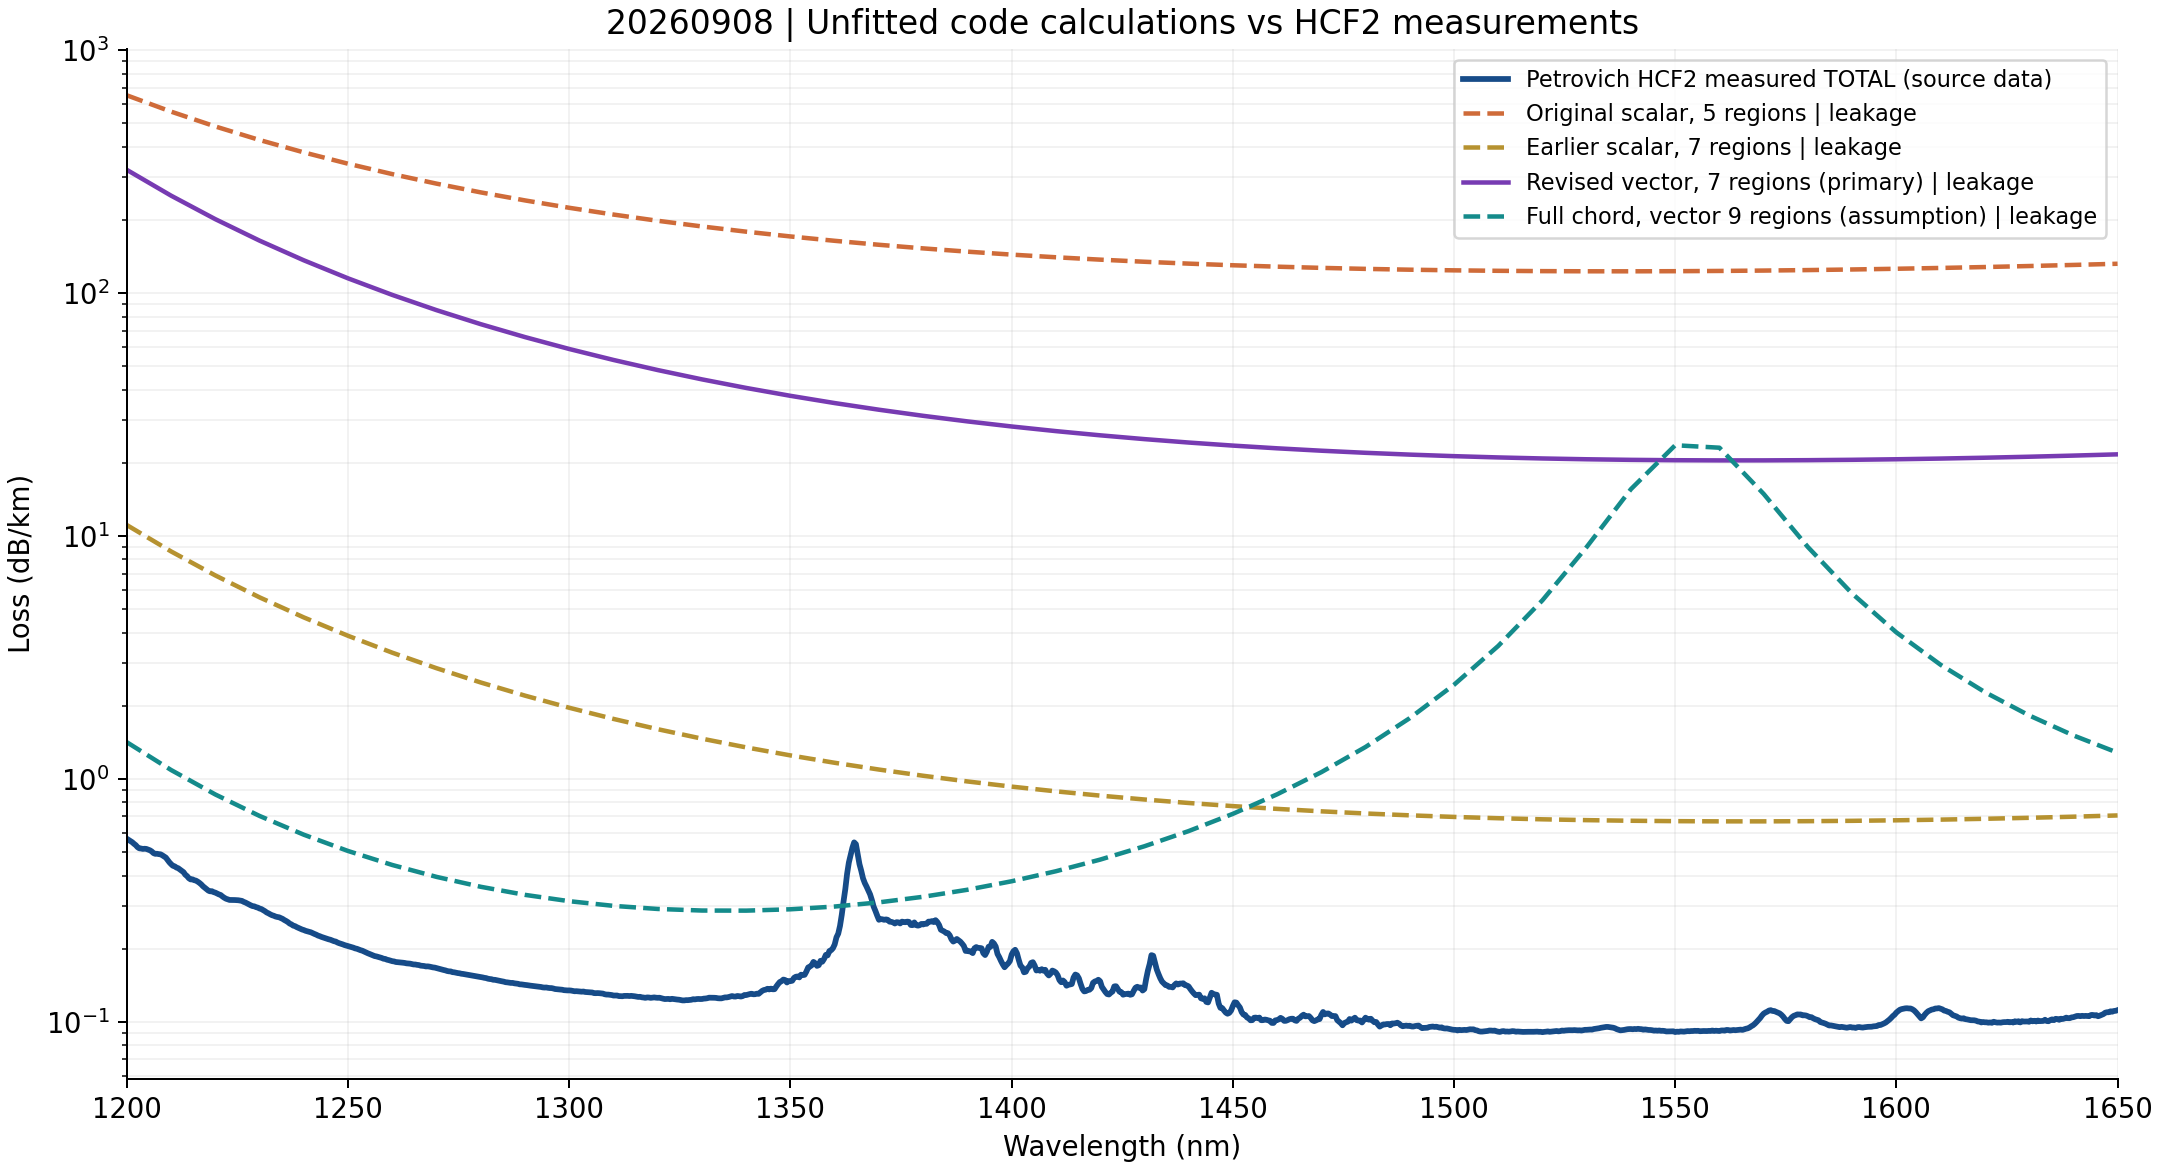

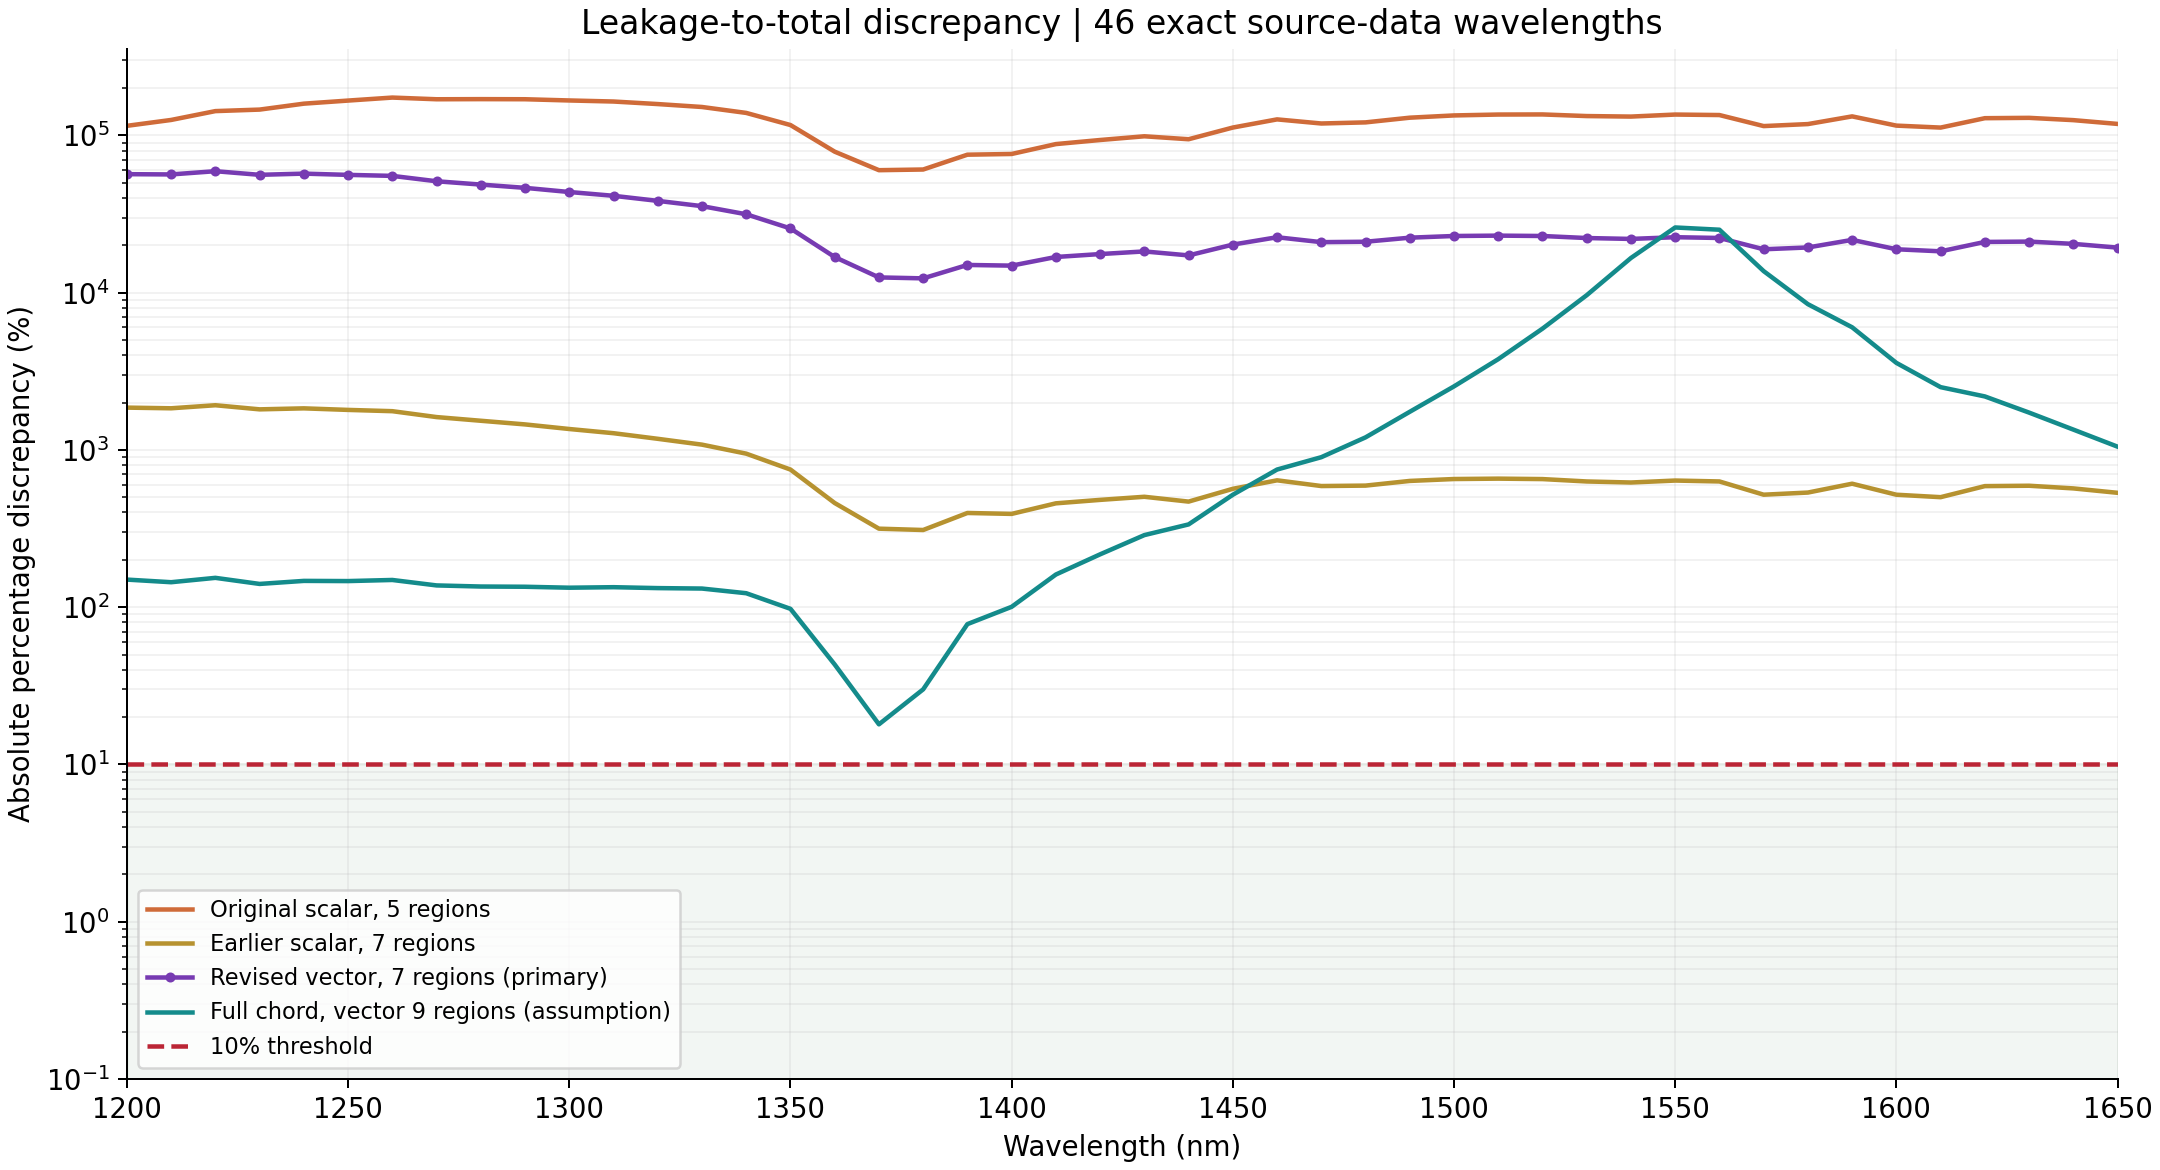

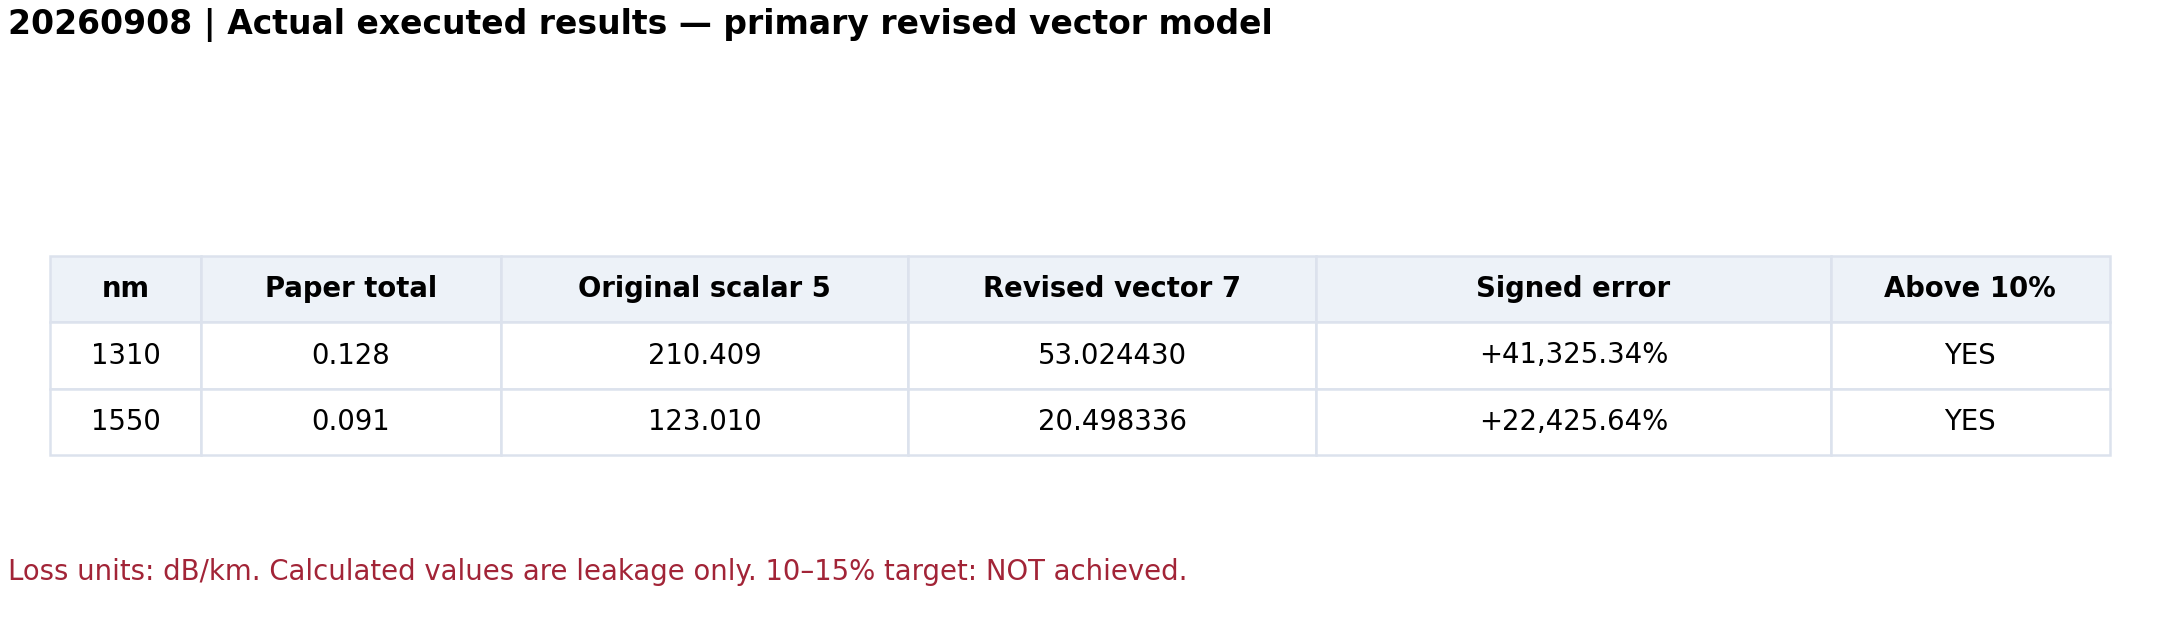

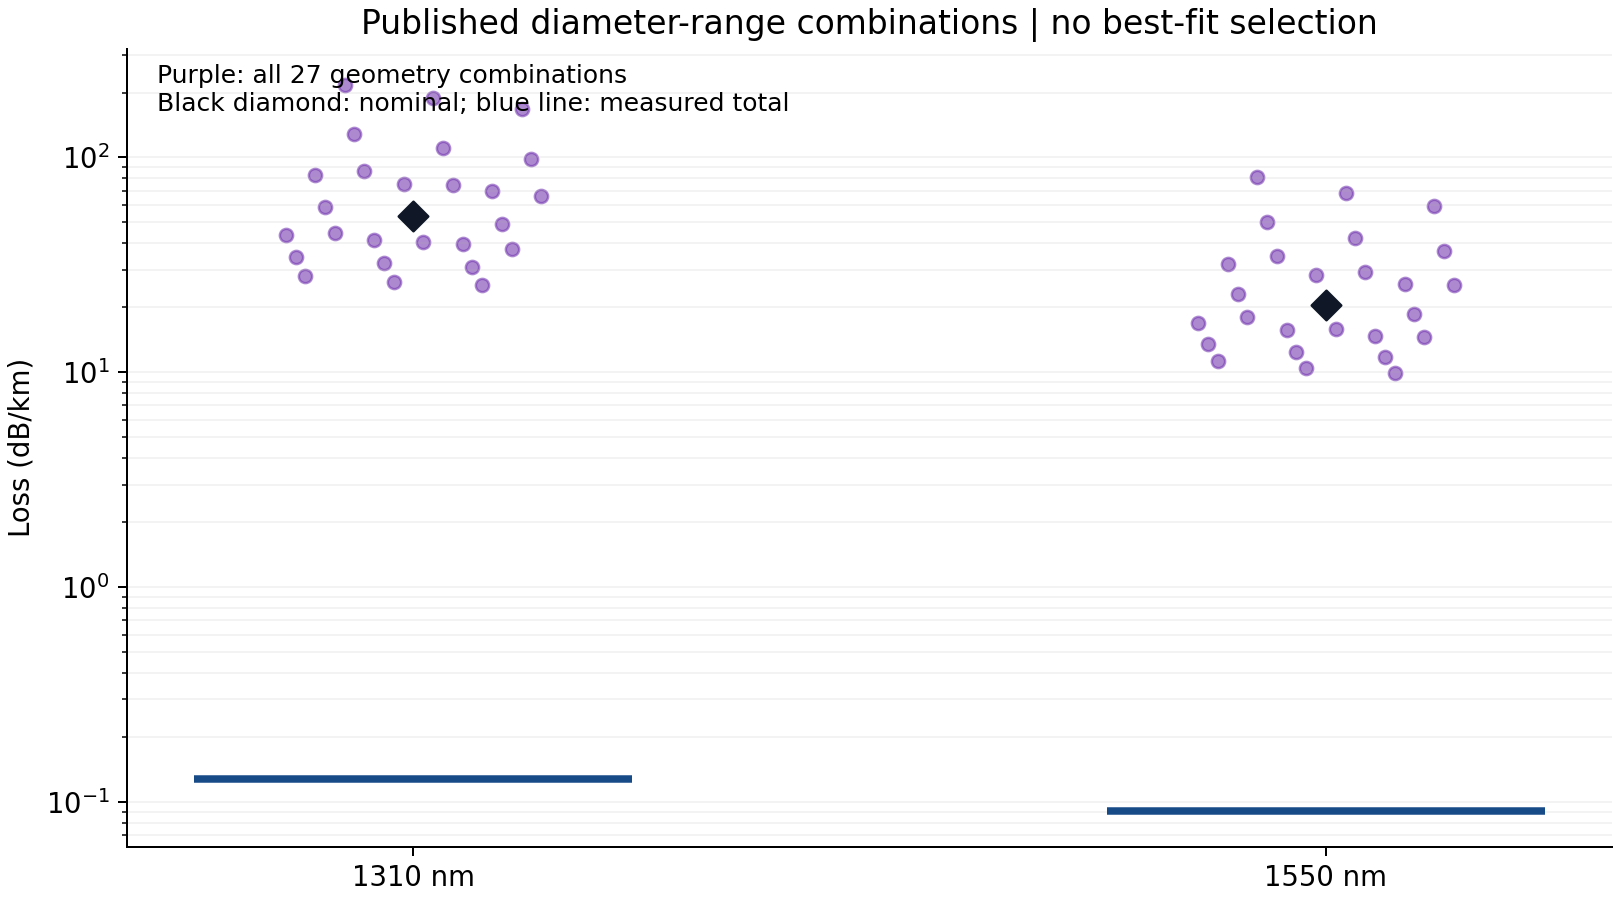

In [14]:
figure_paths=make_plots(predictions,raw,spectral,nominal,sensitivity,Path('.'))
for path in figure_paths:
    display(Image(filename=str(path)))

# 20260908 — 입력 출처, 구현식, 검증 범위

## 비교 기준

- Marco Petrovich et al., **Broadband optical fibre with an attenuation lower than 0.1 decibel per kilometre**, Nature Photonics **19**, 1203–1208 (2025). [DOI](https://doi.org/10.1038/s41566-025-01747-5).
- 비교 섬유는 **HCF2**. 본문 Fig. 2d의 cutback 평균은 1310 nm에서 0.128 dB/km, 1550 nm에서 0.091 dB/km. OTDR 값 0.123/0.095와 혼합하지 않았다. Fig. 1의 보정용 별도 섬유나 HCF1도 사용하지 않았다.
- [Fig. 3 Source Data 원본 XLSX](https://media.springernature.com/original/springer-static/esm/art%3A10.1038%2Fs41566-025-01747-5/MediaObjects/41566_2025_1747_MOESM3_ESM.xlsx)의 `HCF_cutback_loss` 시트를 사용했다. 원본은 `data/petrovich_fig3_source.xlsx`, 추출본은 `data/petrovich_hcf2_cutback_source.csv`에 보존했다. 같은 통합문서의 `gas_free_HCF_loss`는 가스 기여를 제거한 파생 곡선이므로 주 비교에 사용하지 않았다.
- XLSX SHA256: `e74c7cd115146dc93d254c0d26f3f991dd76e7fdb7c52cf7e8271e930f3bb31e`.
- 원자료 1799점: 1200–1919.2 nm, 간격 0.4 nm. 주 다파장 평가는 **1200–1650 nm, 10 nm 간격, 46점**이다. 모든 평가 파장은 원자료에 정확히 존재하며 보간하거나 그림을 digitize하지 않았다. 이 범위는 네 cutback 평균을 보고한 측정 범위에 해당한다. 원자료의 두 점은 0.128206 및 0.090698975 dB/km로, 본문의 반올림값과 별도 집계한다.
- [2025-10-17 정정문](https://doi.org/10.1038/s41566-025-01803-0)은 Fig. 2c의 x축 1200–1500 nm를 1200–1900 nm로 수정했다. 1310/1550 nm 손실값을 바꾸는 정정은 아니다.
- 이 CSV는 원자료 추출물이며 Petrovich et al.에 귀속된다. 원문에 명시된 [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/)에 따라 출처를 표시한다. 원문 전체나 논문 그림은 재배포하지 않았다.

## 계산에 사용한 기하와 가정

| 입력 | 값 (µm) | 근거/한계 |
|---|---:|---|
| 코어 반경 | 14.75 | 논문의 HCF2 nominal diameter 29.5 및 기존 코드 유지; 측정 지름 범위 29.1–29.6 |
| 큰 튜브 지름 | 31.05 | 공개 범위 30.4–31.7의 중간값 |
| 중간 튜브 지름 | 23.75 | 공개 범위 22.7–24.8의 중간값 |
| 작은 튜브 지름 | 7.70 | 공개 범위 7.0–8.4의 중간값 |
| 각 유리막 두께 | 0.50 | 본문 약 500 nm를 모든 막에 동일 적용; 개별 막 측정값 아님 |
| 환산 공기층 g1 | 6.30 | 큰 지름 − 2t − 중간 지름; 튜브가 같은 반경 방향에서 내부 접한다고 가정 |
| 환산 공기층 g2 | 15.05 | 중간 지름 − 2t − 작은 지름; 실제 측정 gap이 아님 |
| 공기 굴절률 | 1 | 진공 근사; 잔류 가스의 압력/조성 및 흡수는 미지 |
| 실리카 굴절률 | 파장별 실수 Sellmeier | 기존 코드 유지. Malitson, JOSA 55, 1205–1209 (1965), [DOI](https://doi.org/10.1364/JOSA.55.001205); 재료 분산 데이터에 대한 문헌식이며 HCF2 손실 fitting은 아님 |

27개 튜브 지름 조합은 각 공개 범위의 하한/중간/상한의 직교 조합이다. 실제 함께 관측된 단면 27개도, 확률분포나 신뢰구간도 아니다. 손실 오차가 가장 작은 조합을 고르지 않는다. 막 두께 분포, 타원도, 접촉 위치, 종방향 상관관계의 불확실성은 이 범위 계산으로 해결되지 않는다.

## 논문별 구현 위치와 적용 한계

1. **David Bird**, *Attenuation of model hollow-core, anti-resonant fibres*, Optics Express **25**, 23215–23237 (2017), [DOI](https://doi.org/10.1364/OE.25.023215). [출판사 제공 전체 원문 미러](https://www.researchgate.net/publication/319695985_Attenuation_of_model_hollow-core_anti-resonant_fibres).
   - Eqs. (4)–(5): 각 영역의 종방향 전기/자기장과 복소 횡파수.
   - Eqs. (6b), (6d), (7)–(8): 접선장 연속 조건. `hcf_vector_tmm._basis`에서 Ez, Z0Hz, Ephi, Z0Hphi 네 성분을 동시에 연결한다. exp(i*m*phi) 표기는 논문의 실수 sin/cos 각도 기저와 동등하다.
   - Eq. (25) 계열의 다층 전달: `reduced_matching`은 외부 outgoing Hankel 기저를 안쪽으로 전파한다. QR은 수치 크기 조절만 수행한다. 정확한 Bessel/Hankel 함수를 사용하고 Eq. (26)의 점근근사는 사용하지 않는다.
   - Eq. (3) 기하 및 **Table 1, HE11, rc/lambda=15, epsilon=2.25, N=1–4**의 정확 수치값을 `bird_benchmark`에서 직접 재계산한다. 논문의 N은 유한층 수로, 본 보고서의 전체 영역 수와 다르다. 표는 소수점 셋째 자리로 반올림되어 있으므로 ±0.0005 허용 폭도 보고한다. Table 2의 손실 최소화 치수는 사용하지 않는다.
   - 동심 구조의 일치는 실제 비원형 5-tube double-nested DNANF의 검증이 아니다.
2. **Morten Bache, Md. Selim Habib, Christos Markos, Jesper Lægsgaard**, *Poor-man’s model of hollow-core anti-resonant fibers*, JOSA B **36**, 69–80 (2019), [DOI](https://doi.org/10.1364/JOSAB.36.000069), [공개 원문](https://arxiv.org/abs/1806.10416).
   - 공개 원문 Eqs. (15), (16), (17)의 TE/TM 손실 및 hybrid 평균은 기존 `bache_bouncing_ray_loss_db_km`로 계산한다. 단일막의 편광 처리 점검에 사용한다.
   - 논문의 FEM 맞춤 스케일 `f_FEM`은 사용하지 않는다. FEM fitting을 포함한 poor-man 모델 전체를 무보정 예측이라고 부르지 않는다. 중첩막에 단일막 계수를 반복 곱하는 임의 손실식도 주 결과로 사용하지 않는다.
3. **Petrovich et al.**의 Methods: 실제 SEM 단면을 이용한 FEM leakage, 표면 산란 및 미세굽힘 등 총손실 항의 정의를 확인한다. 저자들이 15개 섬유에 대해 추정한 경험계수를 이 코드에 이식하지 않는다. 미공개 표면 PSD/굽힘 조건을 0으로 측정되었다고 간주하지 않는다.
4. **Leah R. Murphy & David Bird**, *Azimuthal confinement: the missing ingredient in understanding confinement loss in antiresonant, hollow-core fibers*, Optica **10**, 854–870 (2023), [DOI](https://doi.org/10.1364/OPTICA.492058), [저자 기관 원문 설명](https://researchportal.bath.ac.uk/en/publications/azimuthal-confinement-the-missing-ingredient-in-understanding-con/).
   - 다음 단계의 구조 개선 근거. 방위각 방향 장 구속의 중요성을 설명하므로 동심원 단순화의 한계를 해석하는 데 참고한다. 단일 반공진 유리층에 대해 검증된 식을 double-nested HCF2에 임의 적용하거나 감소 배율을 가져오지 않았다.

## 실제 수정과 검증의 의미

- 기존 `hcf_concentric_tmm_20260908.py`의 scalar 5영역 코드를 그대로 실행해 수정 전 기준으로 사용했다. 이전 scalar 7영역 진단도 다시 실행한다.
- 수정 주 결과는 **vector 7영역**이다. 공개된 세 중첩막을 기존 동심 근사 안에서 유지하면서 scalar m=0의 장/미분 연속을 **m=1 Maxwell 네 접선장 연속 조건**으로 바꿨다. 이는 물리 모델의 수정이며, 실측에 더 가까운 모델을 파장마다 선택한 결과가 아니다.
- 시간/전파 convention은 exp(i beta z − i omega t). Im(beta)>0인 수동 감쇠 해만 허용한다. 손실 변환은 `2*Im(beta)*10/ln(10)`에 길이 단위를 적용한다. 잘못된 부호에 절댓값을 씌우거나 beta를 켤레화해서 통과시키지 않는다.
- 안쪽/바깥쪽 전달의 최소 특이값과 40자리 별도 mpmath 구현으로 1310/1550 nm 근을 검산한다. 이는 같은 Maxwell 문제의 수치 검산이다. Bird 표는 별도 출판 수치 기준이다. 어느 것도 HCF2 FEM 데이터의 대체 검증이 아니다.
- **vector 9영역**은 별도 형상 민감도 진단이다. 동일 선상 내부 접촉을 가정한 세 튜브의 완전한 직경 경로를 유지하면 작은 튜브 내부 공기 6.70 µm와 반대쪽 접촉 유리벽 3t=1.50 µm가 추가된다. 실제 단면을 다시 동심원으로 바꾼 가정이므로 주 결과로 승격하지 않는다. 이 두꺼운 환산 벽의 공진은 인공적인 동심 구조 특성일 수 있다. 특정 파장에서 더 작은 오차가 나와도 선택하지 않는다.
- 알려진 1310/1550 nm 값을 본 뒤 세운 과거 보정 모델은 가져오지 않았다. 기존 개선 노트북에는 목표값을 기저 행렬로 풀어 정한 계수가 있었으므로 독립 계산으로 취급할 수 없다. 이번 예측 함수에는 논문 손실값 입력이 없다. 다만 논문값 자체는 이전 대화에서 이미 알려져 있으므로 완전한 blind 검증은 아니다.

## 10% 초과 시 개선 순서

| 우선순위 | 확인된 사실 / 남은 추정 | 바꿀 코드와 필요한 자료 |
|---|---|---|
| 1 | 동심 모델에는 실제 5개 튜브의 방위각 형상이 없음. Bird 검산 성공은 그 차이를 제거하지 않음 | `geometry_models` 및 Maxwell solver를 실제 2D 단면 기반으로 대체. HCF2의 여러 위치 SEM 윤곽, 개별 막 두께, gap/접촉/타원도, outer jacket 필요. Full-vector FEM/PML에서 mesh, 영역 크기, PML 수렴과 동일 모드 overlap 추적을 수행 |
| 2 | scalar 결과와 vector 결과의 차이가 큼. 모드와 편광 처리는 이미 수정했지만 실제 단면의 cladding-mode coupling은 미계산 | m=1 원통 가정을 해제하고 실제 두 편광과 core/cladding mode overlap, 공진 근처 모드 혼합을 검사. 손실이 가장 작은 고유치만 선택하지 않음 |
| 3 | 계산한 leakage가 실측 total보다 이미 큼. 양의 SSL/µBL/gas 항을 더해서 이 과대예측을 줄일 수 없음 | leakage 구조 검증 후에만 항별 합계 계산. 독립 표면 거칠기 PSD, 코팅/직경/굽힘 PSD 및 설치 조건, 가스 조성/압력/온도 필요. Petrovich 경험계수를 복사해 무보정이라고 표시하지 않음 |
| 4 | 지름 범위만 있고 각 위치의 공동 분포와 막 두께 오차는 없음 | 범위 표를 최적값 탐색으로 쓰지 말고 실제 longitudinal samples로 전파손실 평균 및 불확실성 평가 |

실제 HCF2 총손실 또는 FEM을 대체할 수 있다는 결론은 내릴 수 없다. 계산은 누설손실이므로 실측 총손실과의 백분율은 **총손실 예측 정확도가 아니라 물리량이 다른 두 값의 차이 진단**이다. 다음 버전이 10% 이내라고 보장할 근거는 없다.

In [15]:
primary=nominal_metrics[nominal_metrics.model==PRIMARY_MODEL].iloc[0]
wide=spectral_metrics[spectral_metrics.model==PRIMARY_MODEL].iloc[0]
old=nominal_metrics[nominal_metrics.model=='old_scalar5'].iloc[0]
summary={'primary_model':PRIMARY_MODEL,
         'quantity_warning':'Calculated leakage compared with measured total; not total-loss prediction accuracy',
         'nominal_metrics':nominal_metrics.to_dict(orient='records'),
         'spectral_metrics':spectral_metrics.to_dict(orient='records'),
         'nominal_primary':primary_comparison_table(nominal).to_dict(orient='records'),
         'target_10pct_all_points_met':bool(wide.n_exceeds_10pct==0),
         'target_15pct_all_points_met':bool(wide.n_within_15pct==wide.n),
         'bird_max_APE_pct':float(bird.relative_error_pct.abs().max()),
         'precision_max_difference_pct':float(precision.difference_pct.abs().max()),
         'can_replace_Petrovich_FEM_or_total_loss':False,
         'environment':environment}
(OUT/'summary.json').write_text(json.dumps(summary,indent=2,ensure_ascii=False))
report=f"""수정 주 모델은 vector 7영역 동심 근사입니다. 본문 반올림값 2점 기준 MAPE는 **{primary.MAPE_pct:,.2f}%**, 최대 APE는 **{primary.max_APE_pct:,.2f}%**입니다.

1200–1650 nm 원자료 46점 기준 MAPE는 **{wide.MAPE_pct:,.2f}%**, 최대 APE는 **{wide.max_APE_pct:,.2f}%**, 10% 초과는 **{int(wide.n_exceeds_10pct)}/{int(wide.n)}점**입니다.
기존 scalar 5영역의 같은 2점 MAPE는 **{old.MAPE_pct:,.2f}%**입니다. **10–15% 목표에 도달하지 못했습니다.**

Bird 동심 문제는 표 반올림 범위 안에서 재현했습니다. 이는 DNANF의 실제 5개 튜브, 방위각 구속, 모드 결합 및 종방향 변동을 대체하지 않습니다.
현재 leakage가 측정 total보다 큰 상태에서 양의 산란·미세굽힘 항을 더하는 것으로 과대예측을 해결할 수 없습니다.
실제 SEM 단면을 사용한 full-vector FEM/PML 수렴 검증이 우선이고, 이어서 독립 측정한 표면/굽힘/가스 정보를 더해야 합니다.

실행 위치: 제공된 Python/IPython 커널. Colab 웹 실행을 주장하지 않습니다. 실제 출력이 포함된 20260908.ipynb와 HTML 및 PNG가 제공됩니다."""
display(Markdown(report))
(OUT/'report_ko.md').write_text(report)

수정 주 모델은 vector 7영역 동심 근사입니다. 본문 반올림값 2점 기준 MAPE는 **31,875.49%**, 최대 APE는 **41,325.34%**입니다.

1200–1650 nm 원자료 46점 기준 MAPE는 **29,202.47%**, 최대 APE는 **59,139.12%**, 10% 초과는 **46/46점**입니다.
기존 scalar 5영역의 같은 2점 MAPE는 **149,678.91%**입니다. **10–15% 목표에 도달하지 못했습니다.**

Bird 동심 문제는 표 반올림 범위 안에서 재현했습니다. 이는 DNANF의 실제 5개 튜브, 방위각 구속, 모드 결합 및 종방향 변동을 대체하지 않습니다.
현재 leakage가 측정 total보다 큰 상태에서 양의 산란·미세굽힘 항을 더하는 것으로 과대예측을 해결할 수 없습니다.
실제 SEM 단면을 사용한 full-vector FEM/PML 수렴 검증이 우선이고, 이어서 독립 측정한 표면/굽힘/가스 정보를 더해야 합니다.

실행 위치: 제공된 Python/IPython 커널. Colab 웹 실행을 주장하지 않습니다. 실제 출력이 포함된 20260908.ipynb와 HTML 및 PNG가 제공됩니다.